# Projeto VCPI — Classificação de Sinais de Trânsito (GTSRB)

Trabalho completo: **Fase 1** (data augmentation e treino de modelos) + **Fase 2** (ensembles).

Na Fase 1 treino 14 modelos (2 arquiteturas × 7 estratégias de augmentation) e analiso o impacto de cada técnica de processamento de imagem. O melhor modelo individual a 48×48 chega a 99.48 % de test accuracy.

Na Fase 2 combino as redes num ensemble, chegando a **99.80 %** — ao nível do estado da arte reportado para o GTSRB (~99.82 %).

In [1]:
import os, sys, json, time, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageOps
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, models
from torchvision.transforms import v2

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns

# reprodutibilidade
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# diretorias do projeto
TRAIN_DIR = Path('training_images')
TEST_DIR  = Path('test_images')
CKPT_DIR  = Path('checkpoints'); CKPT_DIR.mkdir(exist_ok=True)
LOG_DIR   = Path('logs');        LOG_DIR.mkdir(exist_ok=True)

# hiperparametros globais (resolução pequena — mediana das imagens originais é ~40 px)
IMG_SIZE    = 48
BATCH_SIZE  = 128
NUM_CLASSES = 43

Device: cuda:0


## Análise Exploratória

In [2]:
# Transform mínimo para EDA
eda_transform = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

full_train_dataset = datasets.ImageFolder(root=str(TRAIN_DIR), transform=eda_transform)
test_dataset_eda   = datasets.ImageFolder(root=str(TEST_DIR),  transform=eda_transform)

print(f'Classes : {len(full_train_dataset.classes)}')
print(f'Treino  : {len(full_train_dataset)}')
print(f'Teste   : {len(test_dataset_eda)}')

Classes : 43
Treino  : 35347
Teste   : 12630


Split estratificado 85/15 — preserva a proporção de cada classe na validação (o GTSRB é desbalanceado, rácio max/min ~10×).

In [3]:
targets = np.array(full_train_dataset.targets)
train_idx, val_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.15, stratify=targets, random_state=SEED,
)
print(f'Treino: {len(train_idx)} | Validação: {len(val_idx)}')

Treino: 30044 | Validação: 5303


Distribuição de classes nos três conjuntos.

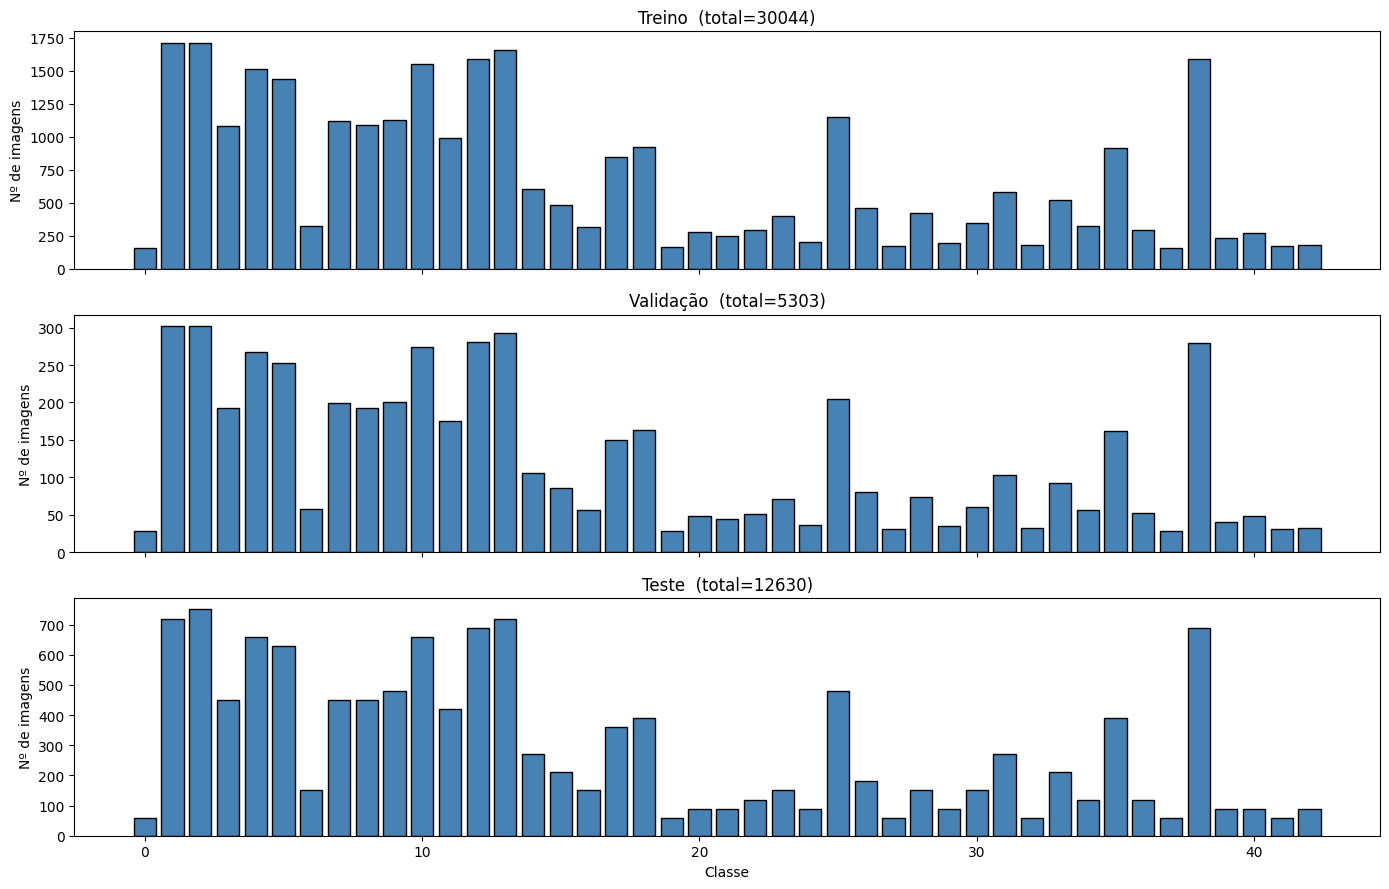

In [4]:
GTSRB_CLASS_NAMES = {
     0: 'Limite 20',         1: 'Limite 30',          2: 'Limite 50',
     3: 'Limite 60',         4: 'Limite 70',          5: 'Limite 80',
     6: 'Fim Limite 80',     7: 'Limite 100',         8: 'Limite 120',
     9: 'Proib. Ultrap.',   10: 'Proib. Ult. >3.5t', 11: 'Pri. cruzam.',
    12: 'Via prioritária', 13: 'Cedência',          14: 'STOP',
    15: 'Via fechada',     16: 'Proib. >3.5t',      17: 'Sentido proibido',
    18: 'Perigo geral',    19: 'Curva esq.',        20: 'Curva dir.',
    21: 'Curva dupla',     22: 'Pavim. irreg.',     23: 'Pavim. esc.',
    24: 'Estreitam. dir.', 25: 'Obras',             26: 'Semáforos',
    27: 'Peões',           28: 'Crianças',          29: 'Bicicletas',
    30: 'Gelo/neve',       31: 'Animais',           32: 'Fim restrições',
    33: 'Vire dir.',       34: 'Vire esq.',         35: 'Em frente',
    36: 'Frente/dir.',     37: 'Frente/esq.',       38: 'Mant. dir.',
    39: 'Mant. esq.',      40: 'Rotunda',           41: 'Fim Proib.Ult.',
    42: 'Fim Proib.Ult.>3.5t',
}

train_counts = Counter([full_train_dataset.targets[i] for i in train_idx])
val_counts   = Counter([full_train_dataset.targets[i] for i in val_idx])
test_counts  = Counter(test_dataset_eda.targets)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, counts, title in zip(
        axes, [train_counts, val_counts, test_counts],
        ['Treino', 'Validação', 'Teste']):
    cs = sorted(counts.keys())
    ax.bar(cs, [counts[c] for c in cs], color='steelblue', edgecolor='black')
    ax.set_title(f'{title}  (total={sum(counts.values())})')
    ax.set_ylabel('Nº de imagens')
axes[-1].set_xlabel('Classe')
plt.tight_layout(); plt.show()

Uma amostra por classe.

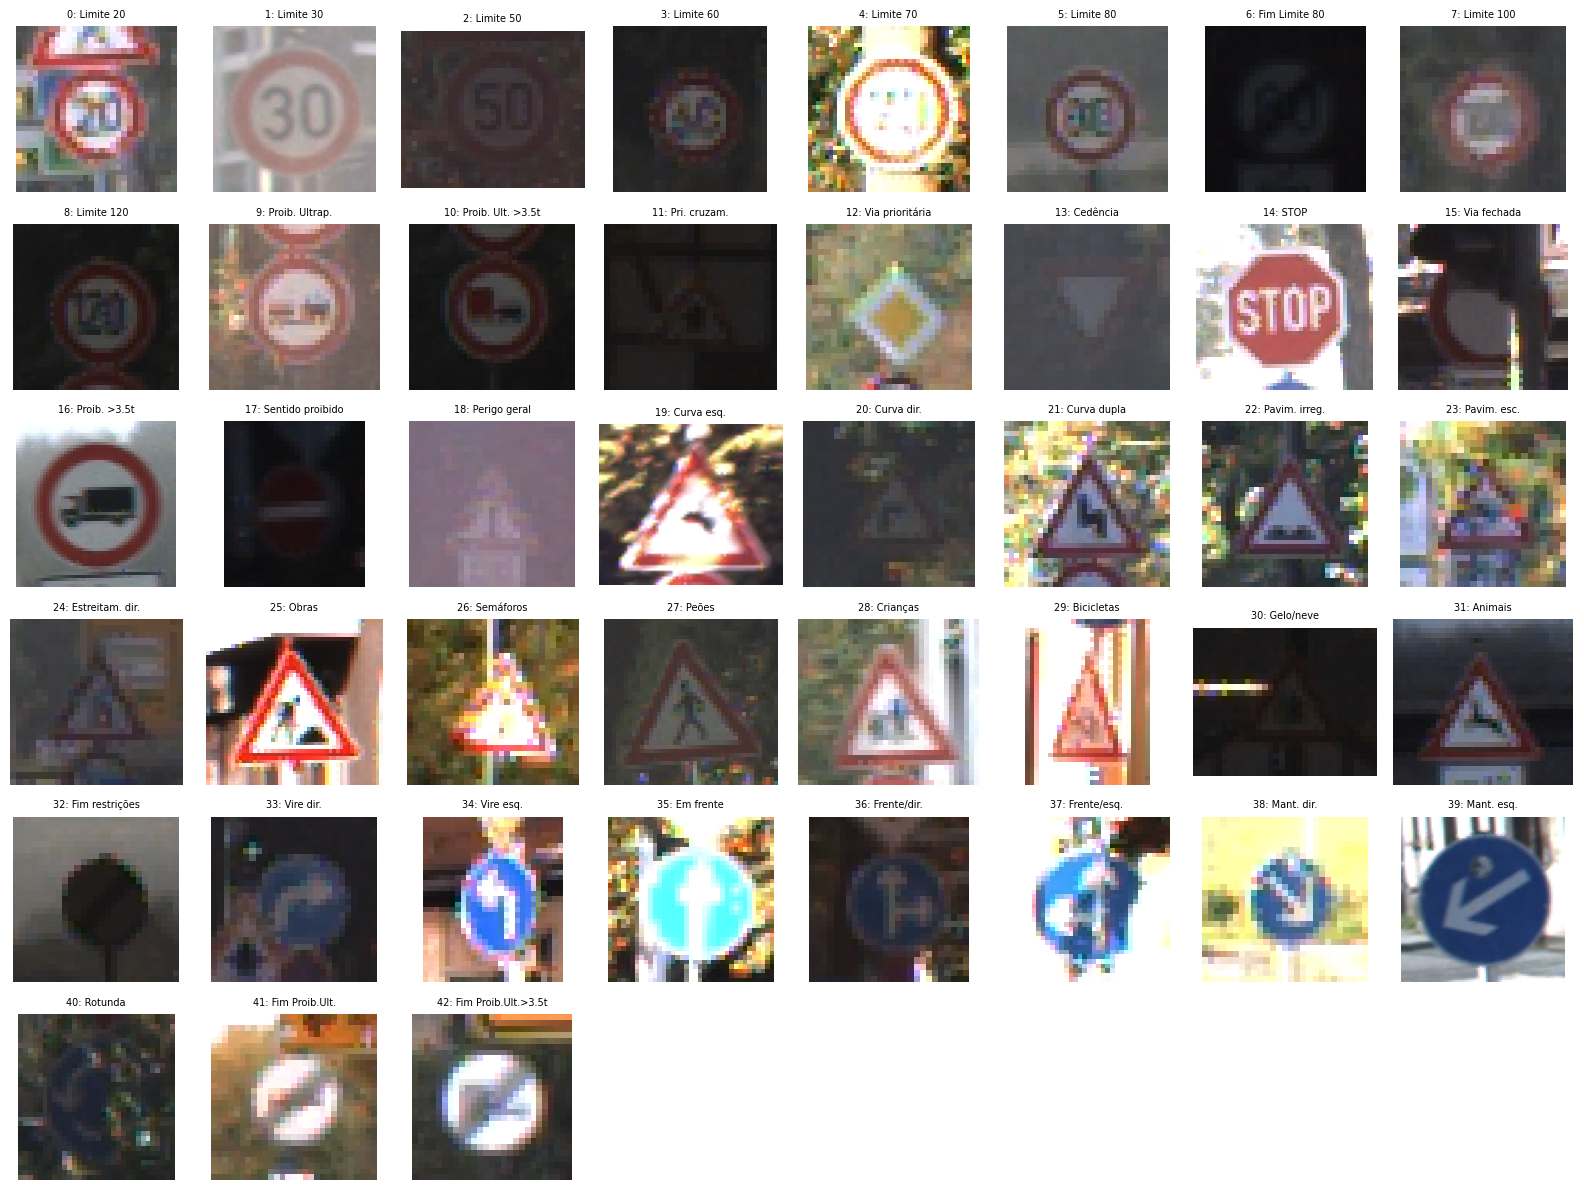

In [5]:
samples = {}
for path, label in full_train_dataset.samples:
    if label not in samples:
        samples[label] = Image.open(path).convert('RGB')
    if len(samples) == NUM_CLASSES:
        break

cols, rows = 8, int(np.ceil(NUM_CLASSES / 8))
fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
for c in range(NUM_CLASSES):
    axes.flat[c].imshow(samples[c])
    axes.flat[c].set_title(f'{c}: {GTSRB_CLASS_NAMES[c]}', fontsize=7)
    axes.flat[c].axis('off')
for j in range(NUM_CLASSES, rows*cols):
    axes.flat[j].axis('off')
plt.tight_layout(); plt.show()

Distribuição de tamanhos originais e brilho médio (amostra de 2000 imagens).

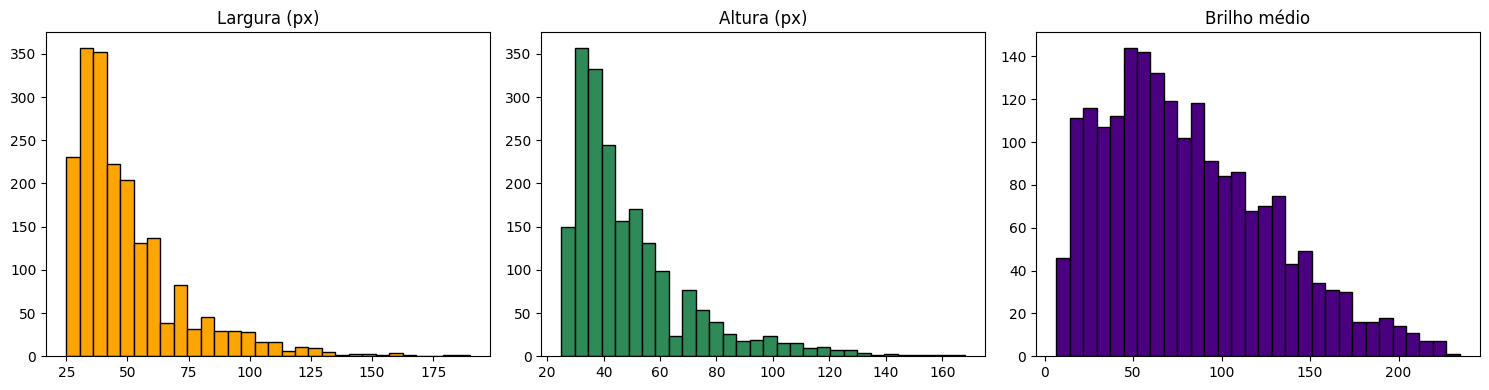

Tamanhos: min=25x25  max=190x168
Brilho: média=81.6  std=47.2


In [6]:
widths, heights, brightness = [], [], []
for path, _ in random.sample(full_train_dataset.samples, k=2000):
    with Image.open(path) as im:
        widths.append(im.width)
        heights.append(im.height)
        brightness.append(np.array(im.convert('L')).mean())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(widths,     bins=30, color='orange',   edgecolor='k'); axes[0].set_title('Largura (px)')
axes[1].hist(heights,    bins=30, color='seagreen', edgecolor='k'); axes[1].set_title('Altura (px)')
axes[2].hist(brightness, bins=30, color='indigo',   edgecolor='k'); axes[2].set_title('Brilho médio')
plt.tight_layout(); plt.show()

print(f'Tamanhos: min={min(widths)}x{min(heights)}  max={max(widths)}x{max(heights)}')
print(f'Brilho: média={np.mean(brightness):.1f}  std={np.std(brightness):.1f}')

## Pré-processamento e Data Augmentation

Cálculo do `mean/std` do treino para normalização (guardado em cache).

In [7]:
STATS_PATH = Path(f'dataset_stats_{IMG_SIZE}.npz')

# cache em disco — calcular mean/std a partir de 33k imagens demora alguns segundos
if STATS_PATH.exists():
    _st = np.load(STATS_PATH)
    DATASET_MEAN = _st['mean'].tolist()
    DATASET_STD  = _st['std'].tolist()
else:
    # mean/std por canal, computados em "single pass" com somas e somas dos quadrados
    loader = DataLoader(Subset(full_train_dataset, train_idx),
                        batch_size=256, shuffle=False)
    n, s, s2 = 0, torch.zeros(3), torch.zeros(3)
    for imgs, _ in loader:
        b, c, h, w = imgs.shape
        n  += b * h * w
        s  += imgs.sum(dim=[0, 2, 3])
        s2 += (imgs ** 2).sum(dim=[0, 2, 3])
    mean = s / n
    std  = (s2 / n - mean ** 2).sqrt()
    DATASET_MEAN, DATASET_STD = mean.tolist(), std.tolist()
    np.savez(STATS_PATH, mean=mean.numpy(), std=std.numpy())

print(f'Mean: {[round(v, 4) for v in DATASET_MEAN]}')
print(f'Std : {[round(v, 4) for v in DATASET_STD]}')

Mean: [0.34, 0.312, 0.3213]
Std : [0.2744, 0.2635, 0.27]


Comparação visual de filtros clássicos (CLAHE, equalização global, sharpen, blur) numa imagem escura. CLAHE é a melhor opção para sinais — equalização local sem amplificar ruído.

**CLAHE** (*Contrast Limited Adaptive Histogram Equalization*) — variante do CLAHE clássico que divide a imagem em pequenas regiões (*tiles*) e equaliza o histograma de cada uma localmente, com um limite (*clip limit*) que evita amplificar o ruído. Ao contrário da equalização global, preserva a informação local e não satura zonas já bem iluminadas.

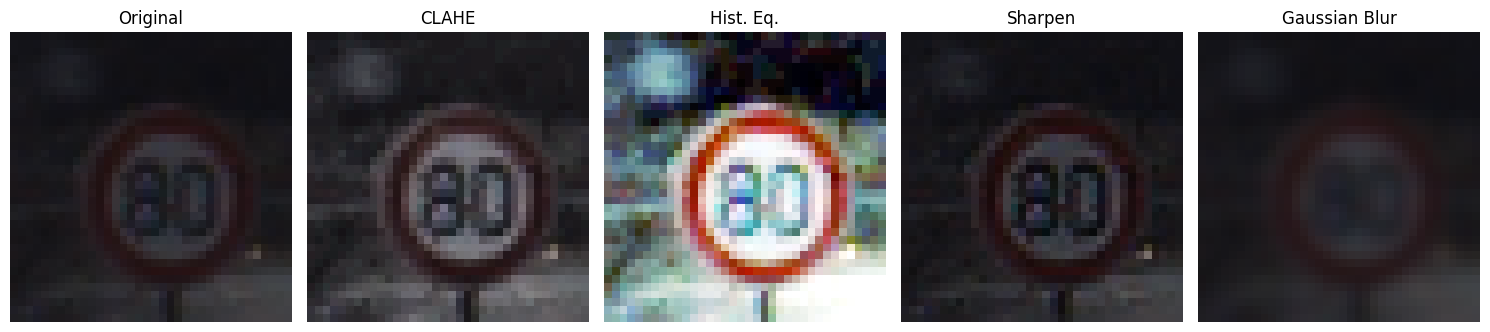

In [8]:
def apply_clahe(img_pil, clip_limit=2.0, tile=(4, 4)):
    # CLAHE aplicado só ao canal L (luminância) do espaço LAB,
    # para equalizar contraste localmente sem distorcer as cores (a, b ficam intactos)
    arr = np.array(img_pil)
    lab = cv2.cvtColor(arr, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile)
    lab[..., 0] = clahe.apply(lab[..., 0])
    return Image.fromarray(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB))

# procurar uma imagem suficientemente escura para o efeito do CLAHE ser visível
dark = Image.open(full_train_dataset.samples[0][0]).convert('RGB')
for path, _ in random.sample(full_train_dataset.samples, 500):
    im = Image.open(path).convert('RGB')
    if np.array(im.convert('L')).mean() < 60:
        dark = im; break

filters = {
    'Original':      dark,
    'CLAHE':         apply_clahe(dark),
    'Hist. Eq.':     ImageOps.equalize(dark),
    'Sharpen':       dark.filter(ImageFilter.SHARPEN),
    'Gaussian Blur': dark.filter(ImageFilter.GaussianBlur(radius=1.0)),
}
fig, axes = plt.subplots(1, len(filters), figsize=(3*len(filters), 3.5))
for ax, (name, im) in zip(axes, filters.items()):
    ax.imshow(im); ax.set_title(name); ax.axis('off')
plt.tight_layout(); plt.show()

Transforms custom para usar dentro de `v2.Compose`.

In [9]:
# wrappers para usar dentro de v2.Compose (recebem PIL e devolvem PIL)
class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(4, 4), p=1.0):
        self.cl, self.t, self.p = clip_limit, tile_grid_size, p
    def __call__(self, img):
        return img if random.random() > self.p else apply_clahe(img, self.cl, self.t)

class RandomGaussianBlur:
    def __init__(self, radius_range=(0.1, 1.0), p=0.2):
        self.rr, self.p = radius_range, p
    def __call__(self, img):
        if random.random() > self.p:
            return img
        return img.filter(ImageFilter.GaussianBlur(radius=random.uniform(*self.rr)))

Defini 7 estratégias de augmentation com complexidade crescente, para tentar isolar o efeito de cada componente.

| Estratégia | Componentes |
|---|---|
| A_baseline    | só Resize + Normalize |
| B_geo_light   | + RandomAffine leve |
| C_geo_heavy   | + RandomAffine + Perspetiva |
| D_photo       | + ColorJitter |
| E_combo       | C + D + RandomGaussianBlur |
| F_clahe_combo | E precedido de CLAHE |
| G_full        | F + RandomErasing |

Não incluí `RandomHorizontalFlip` (viraria sinais como "vire à direita") e mantive as rotações até ±15°.

In [10]:
# blocos comuns reutilizados em todas as estratégias
TO_TENSOR = [v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]
NORMALIZE = v2.Normalize(mean=DATASET_MEAN, std=DATASET_STD)
RESIZE    = v2.Resize((IMG_SIZE, IMG_SIZE))

# A — baseline: só resize + normalização (controlo)
transform_A = v2.Compose([RESIZE, *TO_TENSOR, NORMALIZE])

# B — geo leve: pequenas rotações + translações
transform_B = v2.Compose([
    RESIZE,
    v2.RandomAffine(degrees=10, translate=[0.05, 0.05]),
    *TO_TENSOR, NORMALIZE])

# C — geo pesado: + scale, shear e perspetiva
transform_C = v2.Compose([
    RESIZE,
    v2.RandomAffine(degrees=15, translate=[0.1, 0.1], scale=(0.85, 1.15), shear=10),
    v2.RandomPerspective(distortion_scale=0.2, p=0.5),
    *TO_TENSOR, NORMALIZE])

# D — fotométrico: jitter de brilho/contraste/saturação/hue
transform_D = v2.Compose([
    RESIZE,
    v2.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.05),
    *TO_TENSOR, NORMALIZE])

# E — combo: geo pesado + fotométrico + blur aleatório
transform_E = v2.Compose([
    RESIZE,
    v2.RandomAffine(degrees=15, translate=[0.1, 0.1], scale=(0.85, 1.15), shear=10),
    v2.RandomPerspective(distortion_scale=0.2, p=0.5),
    v2.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.05),
    RandomGaussianBlur(),
    *TO_TENSOR, NORMALIZE])

# F — combo + CLAHE no pré-processamento (jitter mais suave porque CLAHE já normaliza luminância)
transform_F = v2.Compose([
    CLAHETransform(p=1.0),
    RESIZE,
    v2.RandomAffine(degrees=15, translate=[0.1, 0.1], scale=(0.85, 1.15), shear=10),
    v2.RandomPerspective(distortion_scale=0.2, p=0.5),
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    *TO_TENSOR, NORMALIZE])

# G — F + RandomErasing (regularização extra estilo cutout)
transform_G = v2.Compose([
    CLAHETransform(p=1.0),
    RESIZE,
    v2.RandomAffine(degrees=15, translate=[0.1, 0.1], scale=(0.85, 1.15), shear=10),
    v2.RandomPerspective(distortion_scale=0.2, p=0.5),
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    *TO_TENSOR, NORMALIZE,
    v2.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3))])

# avaliação: sem augmentation. CLAHE também aplicado em val/test se usado no treino
# (manter o pre-processamento coerente entre train e eval)
transform_eval       = v2.Compose([RESIZE, *TO_TENSOR, NORMALIZE])
transform_eval_clahe = v2.Compose([CLAHETransform(p=1.0), RESIZE, *TO_TENSOR, NORMALIZE])

AUGMENT_STRATEGIES = {
    'A_baseline':    transform_A,
    'B_geo_light':   transform_B,
    'C_geo_heavy':   transform_C,
    'D_photo':       transform_D,
    'E_combo':       transform_E,
    'F_clahe_combo': transform_F,
    'G_full':        transform_G,
}
EVAL_USES_CLAHE = {'F_clahe_combo', 'G_full'}

Visualização das 7 estratégias na mesma imagem (6 amostras estocásticas cada).

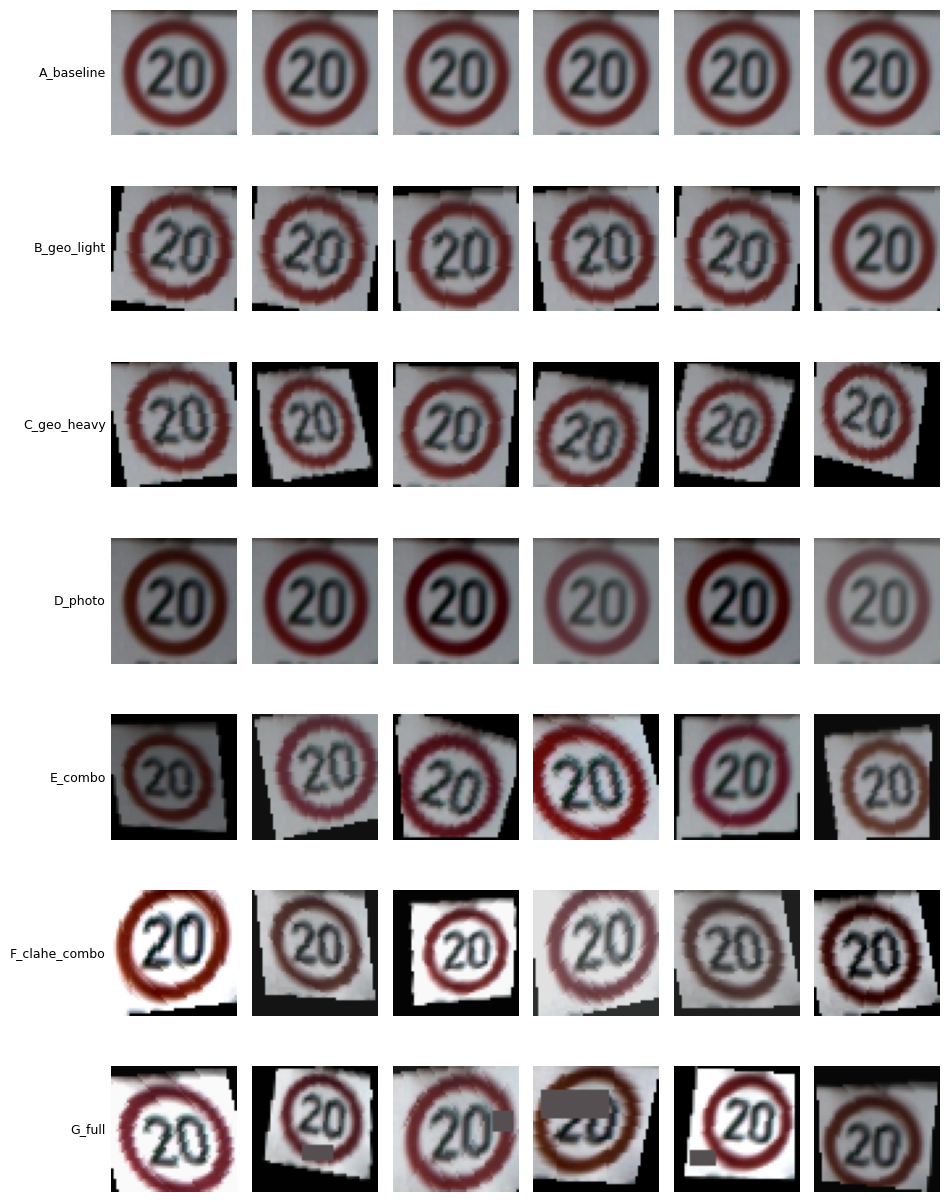

In [11]:
example_pil = Image.open(full_train_dataset.samples[100][0]).convert('RGB')
mean_t = torch.tensor(DATASET_MEAN).view(3, 1, 1)
std_t  = torch.tensor(DATASET_STD).view(3, 1, 1)

n_samples = 6
n_strats  = len(AUGMENT_STRATEGIES)
fig, axes = plt.subplots(n_strats, n_samples, figsize=(n_samples*1.6, n_strats*1.8))
for row, (name, tfm) in enumerate(AUGMENT_STRATEGIES.items()):
    for col in range(n_samples):
        out = (tfm(example_pil) * std_t + mean_t).clamp(0, 1)
        axes[row, col].imshow(out.permute(1, 2, 0).numpy())
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(name, rotation=0, ha='right', va='center', fontsize=9)
    axes[row, 0].set_axis_on()
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    for s in axes[row, 0].spines.values():
        s.set_visible(False)
plt.tight_layout(); plt.show()

Função `build_loaders` — devolve `(train, val, test)` para uma dada estratégia.

In [12]:
def make_weighted_sampler(indices, full_targets):
    # pesos = 1/n_classe, para que classes raras sejam amostradas com mais frequência
    tgt = np.array([full_targets[i] for i in indices])
    cw  = {c: 1.0/n for c, n in Counter(tgt).items()}
    w   = np.array([cw[t] for t in tgt], dtype=np.float64)
    return WeightedRandomSampler(weights=w, num_samples=len(w), replacement=True)

def build_loaders(strategy_name, batch_size=BATCH_SIZE, use_weighted_sampler=False):
    # nota: train e val/test usam *o mesmo* ImageFolder, com transforms diferentes
    train_tfm = AUGMENT_STRATEGIES[strategy_name]
    eval_tfm  = transform_eval_clahe if strategy_name in EVAL_USES_CLAHE else transform_eval

    train_set_full = datasets.ImageFolder(root=str(TRAIN_DIR), transform=train_tfm)
    val_set_full   = datasets.ImageFolder(root=str(TRAIN_DIR), transform=eval_tfm)
    test_set       = datasets.ImageFolder(root=str(TEST_DIR),  transform=eval_tfm)

    # split treino/val feito por índices (estratificado, fixo via SEED)
    train_set = Subset(train_set_full, train_idx)
    val_set   = Subset(val_set_full,   val_idx)

    pin = (device.type == 'cuda')
    if use_weighted_sampler:
        # com sampler não se pode passar shuffle=True
        sampler = make_weighted_sampler(train_idx, train_set_full.targets)
        train_loader = DataLoader(train_set, batch_size=batch_size, sampler=sampler, pin_memory=pin)
    else:
        train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, pin_memory=pin)
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, pin_memory=pin)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, pin_memory=pin)
    return train_loader, val_loader, test_loader

## Arquiteturas

Para ter diversidade no ensemble da Fase 2, decidi treinar duas arquiteturas diferentes:

1. **Conv_VCPI** — CNN (*Convolutional Neural Network*) custom estilo VGG (*Visual Geometry Group*), com 3 blocos convolucionais + GAP (*Global Average Pooling*) + FC (*Fully Connected*). Cerca de 332 k parâmetros.
2. **ResNet18** (*Residual Network* com 18 camadas) pretrained no ImageNet, com a última camada FC  adaptada para 43 classes (*transfer learning*).

**Nota sobre `Dropout2d`** (não visto em aula — nas aulas o dropout é o standard `nn.Dropout` em camadas FC): em vez de fazer dropout independente por *pixel* num feature map, o `Dropout2d` desativa *canais inteiros* duma feature map convolucional com probabilidade *p*. Faz mais sentido em conv layers porque pixels adjacentes num mesmo canal estão fortemente correlacionados — dropout pixel-a-pixel é quase um *no-op* informacional. Mantenho `nn.Dropout` clássico só na FC final.

In [13]:
# bloco standard estilo VGG: 2× (conv 3x3 + BN + ReLU) + maxpool + dropout
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.pool  = nn.MaxPool2d(2)
        self.drop  = nn.Dropout2d(dropout)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)), inplace=True)
        x = F.relu(self.bn2(self.conv2(x)), inplace=True)
        return self.drop(self.pool(x))

# 3 blocos (48→24→12→6) + GAP + 1 FC. ~332k parâmetros.
class Conv_VCPI(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        # dropout cresce com a profundidade — mais regularização nas features mais abstratas
        self.block1 = ConvBlock(3,   32, dropout=dropout * 0.5)
        self.block2 = ConvBlock(32,  64, dropout=dropout * 0.7)
        self.block3 = ConvBlock(64, 128, dropout=dropout)
        self.gap    = nn.AdaptiveAvgPool2d(1)  # GAP em vez de flatten — menos parâmetros, mais robusto
        self.fc1    = nn.Linear(128, 256)
        self.bn_fc  = nn.BatchNorm1d(256)
        self.drop_fc = nn.Dropout(dropout)
        self.fc2    = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.block1(x); x = self.block2(x); x = self.block3(x)
        x = self.gap(x).flatten(1)
        x = F.relu(self.bn_fc(self.fc1(x)), inplace=True)
        x = self.drop_fc(x)
        return self.fc2(x)

def get_conv_vcpi():
    return Conv_VCPI()

def get_resnet18():
    # ResNet18 pretrained no ImageNet, com a head substituída para 43 classes
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model


## Training Loop

AdamW + ReduceLROnPlateau + early stopping (em `val_loss`) + mixed precision. Guarda o melhor checkpoint por experiência em `checkpoints/<arch>/<strategy>/`.

**Notas sobre escolhas que vão além do que foi visto nas aulas:**

- **`AdamW` em vez de `Adam`.** Desacopla o `weight_decay` do passo adaptativo — no Adam, o termo L2 é incorporado no gradiente e acaba a ser escalado pelo segundo momento, o que enfraquece a regularização nos parâmetros com gradientes grandes. O AdamW (Loshchilov & Hutter, ICLR 2019) aplica o decay diretamente aos pesos, o que torna o efeito mais previsível. Mantenho `weight_decay=1e-4` em todas as experiências.

- **Mixed precision (`torch.amp` + `GradScaler`).** Vi que era possível treinar em FP16 (*Floating Point* de 16 bits) em vez de FP32 (*Floating Point* de 32 bits) e decidi experimentar. Na prática o treino ficou bastante mais rápido e usou menos memória na GPU (*Graphics Processing Unit*), o que me permitiu usar `batch_size=128` sem problemas. O `GradScaler` serve para evitar que alguns gradientes muito pequenos percam precisão em FP16 — sem ele o treino pode tornar-se instável. Não notei qualquer diferença na accuracy final.

- **Early stopping explícito.** Em vez de treinar sempre N épocas e ficar com o último estado, monitorizo `val_loss` e guardo *só* o melhor checkpoint; corto o treino se não melhorar por 7 épocas consecutivas. Evita overfitting nas últimas épocas e poupa tempo (no GTSRB várias experiências param ao fim de ~20 épocas em vez das 30 configuradas).

- **`torchvision.transforms.v2`.** A API (*Application Programming Interface*) nova substitui a `transforms` clássica. As únicas vantagens práticas que uso aqui são suporte nativo a `RandomPerspective` mais robusto e composição mais consistente com tensores. Não muda o comportamento dos transforms já vistos nas aulas.

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, scaler=None):
    model.train()
    total_loss, total_correct, total_n = 0.0, 0, 0
    for imgs, lbls in loader:
        imgs = imgs.to(device, non_blocking=True)
        lbls = lbls.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        if scaler is not None:
            # mixed precision (FP16 forward + FP32 master weights) — acelera ~2× em GPUs modernas
            with torch.amp.autocast(device_type='cuda'):
                logits = model(imgs)
                loss = criterion(logits, lbls)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(imgs)
            loss = criterion(logits, lbls)
            loss.backward()
            optimizer.step()
        total_loss    += loss.item() * imgs.size(0)
        total_correct += (logits.argmax(1) == lbls).sum().item()
        total_n       += imgs.size(0)
    return total_loss/total_n, total_correct/total_n

@torch.no_grad()  # desliga gradientes para poupar memória e ser mais rápido
def evaluate(model, loader, criterion):
    model.eval()  # importante: desliga dropout e congela BatchNorm
    total_loss, total_correct, total_n = 0.0, 0, 0
    for imgs, lbls in loader:
        imgs = imgs.to(device, non_blocking=True)
        lbls = lbls.to(device, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, lbls)
        total_loss    += loss.item() * imgs.size(0)
        total_correct += (logits.argmax(1) == lbls).sum().item()
        total_n       += imgs.size(0)
    return total_loss/total_n, total_correct/total_n

@torch.no_grad()
def predict(model, loader):
    # devolve labels reais, previsões e logits — usado para matriz de confusão e análise de erros
    model.eval()
    all_lbl, all_pred, all_logits = [], [], []
    for imgs, lbls in loader:
        imgs = imgs.to(device, non_blocking=True)
        logits = model(imgs)
        all_lbl.extend(lbls.tolist())
        all_pred.extend(logits.argmax(1).cpu().tolist())
        all_logits.append(logits.cpu())
    return all_lbl, all_pred, torch.cat(all_logits, dim=0)

In [15]:
def train_model(model_factory, strategy_name, arch_name,
                epochs=30, patience=7, lr=1e-3, weight_decay=1e-4,
                use_weighted_sampler=False):
    # reset de seeds para que cada experiência seja reproduzível independentemente
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    train_loader, val_loader, test_loader = build_loaders(strategy_name, use_weighted_sampler=use_weighted_sampler)

    model     = model_factory().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    # reduz LR a metade quando val_loss estagna por 3 épocas
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)
    scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None

    suffix = '_weighted' if use_weighted_sampler else ''
    save_path = CKPT_DIR / arch_name / f'{strategy_name}{suffix}'
    save_path.mkdir(parents=True, exist_ok=True)
    best_ckpt = save_path / 'best.pt'

    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': [], 'lr': []}
    best_val_loss, epochs_no_improve = float('inf'), 0
    t_start = time.time()

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(va_loss)

        history['loss'].append(tr_loss); history['accuracy'].append(tr_acc)
        history['val_loss'].append(va_loss); history['val_accuracy'].append(va_acc)
        history['lr'].append(current_lr)

        print(f'  [{epoch:02d}/{epochs}] loss={tr_loss:.4f} acc={tr_acc:.4f}  '
              f'val_loss={va_loss:.4f} val_acc={va_acc:.4f}  lr={current_lr:.2e}')

        # guarda o melhor checkpoint (por val_loss) — early stopping se não melhorar `patience` épocas
        if va_loss < best_val_loss:
            best_val_loss, epochs_no_improve = va_loss, 0
            torch.save({'model': model.state_dict(), 'epoch': epoch,
                        'val_loss': va_loss, 'val_acc': va_acc,
                        'arch': arch_name, 'strategy': strategy_name}, best_ckpt)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'  early stop @ epoch {epoch}')
                break

    elapsed = time.time() - t_start
    # avaliação final feita com o *melhor* checkpoint, não com os pesos da última época
    model.load_state_dict(torch.load(best_ckpt, weights_only=False)['model'])
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    result = {
        'arch': arch_name, 'strategy': strategy_name,
        'best_val_loss': best_val_loss,
        'best_val_acc':  max(history['val_accuracy']),
        'test_acc': test_acc, 'test_loss': test_loss,
        'epochs_run': len(history['loss']), 'time_min': elapsed / 60,
        'ckpt_path': str(best_ckpt), 'history': history,
    }
    with open(LOG_DIR / f'{arch_name}__{strategy_name}{suffix}.json', 'w') as f:
        json.dump(result, f, indent=2)
    print(f'  ✓ test={test_acc:.4f} | {result["epochs_run"]} ep | {result["time_min"]:.1f} min')
    return result

## Treinar os 14 modelos

2 arquiteturas × 7 estratégias. O loop salta modelos já treinados (cache em checkpoints/). Para re-treinar, apagar a pasta correspondente. `SKIP_IF_DONE` salta modelos já treinados.

In [16]:
# Conv_VCPI até 30 épocas, ResNet18 até 20 (converge mais rápido por estar pretrained)
ARCHITECTURES = [
    ('Conv_VCPI', get_conv_vcpi, 30),
    ('ResNet18',  get_resnet18,  20),
]
STRATEGIES = list(AUGMENT_STRATEGIES.keys())
EXPERIMENTS = [(a, f, s, e) for (a, f, e) in ARCHITECTURES for s in STRATEGIES]

SKIP_IF_DONE = True  # se já existe checkpoint+log, só recarrega o resultado
all_results = {}

for arch_name, fn, strategy, n_epochs in EXPERIMENTS:
    key     = f'{arch_name}__{strategy}'
    ckpt    = CKPT_DIR / arch_name / strategy / 'best.pt'
    log_pth = LOG_DIR / f'{key}.json'
    if SKIP_IF_DONE and ckpt.exists() and log_pth.exists():
        with open(log_pth) as f:
            all_results[key] = json.load(f)
        print(f'[skip] {key} (test_acc={all_results[key]["test_acc"]:.4f})')
        continue
    print(f'\n=== {arch_name} × {strategy} ({n_epochs} epochs max) ===')
    all_results[key] = train_model(fn, strategy, arch_name, epochs=n_epochs)

[skip] Conv_VCPI__A_baseline (test_acc=0.9876)
[skip] Conv_VCPI__B_geo_light (test_acc=0.9895)
[skip] Conv_VCPI__C_geo_heavy (test_acc=0.9898)
[skip] Conv_VCPI__D_photo (test_acc=0.9868)
[skip] Conv_VCPI__E_combo (test_acc=0.9922)
[skip] Conv_VCPI__F_clahe_combo (test_acc=0.9948)
[skip] Conv_VCPI__G_full (test_acc=0.9943)
[skip] ResNet18__A_baseline (test_acc=0.9816)
[skip] ResNet18__B_geo_light (test_acc=0.9845)
[skip] ResNet18__C_geo_heavy (test_acc=0.9875)
[skip] ResNet18__D_photo (test_acc=0.9816)
[skip] ResNet18__E_combo (test_acc=0.9910)
[skip] ResNet18__F_clahe_combo (test_acc=0.9898)
[skip] ResNet18__G_full (test_acc=0.9926)


## Resultados

In [17]:
df = pd.DataFrame([{
    'arch':         r['arch'],
    'estratégia':   r['strategy'],
    'test_acc':     r['test_acc'],
    'best_val_acc': r['best_val_acc'],
    'épocas':       r['epochs_run'],
    'tempo (min)':  r['time_min'],
} for r in all_results.values()]).sort_values('test_acc', ascending=False).reset_index(drop=True)

print(df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
df.to_csv(LOG_DIR / 'results_phase1.csv', index=False)

     arch    estratégia  test_acc  best_val_acc  épocas  tempo (min)
Conv_VCPI F_clahe_combo    0.9948        0.9992      30      37.8889
Conv_VCPI        G_full    0.9943        0.9994      30      34.3999
 ResNet18        G_full    0.9926        0.9994      23      30.9562
Conv_VCPI       E_combo    0.9922        0.9996      30      21.0546
 ResNet18       E_combo    0.9910        0.9994      30      35.3985
Conv_VCPI   C_geo_heavy    0.9898        0.9996      30      16.7040
 ResNet18 F_clahe_combo    0.9898        0.9996      30      39.5208
Conv_VCPI   B_geo_light    0.9895        0.9998      30      14.0443
Conv_VCPI    A_baseline    0.9876        1.0000      28      10.1476
 ResNet18   C_geo_heavy    0.9875        0.9992      26      14.8495
Conv_VCPI       D_photo    0.9868        0.9996      30      19.0904
 ResNet18   B_geo_light    0.9845        1.0000      30      15.4300
 ResNet18    A_baseline    0.9816        0.9994      26       9.4130
 ResNet18       D_photo    0.9816 

Pondo as estratégias por ordem aproximada de resultado (média entre as duas arquiteturas):

`A < D ≈ B < C < E < F ≈ G`

Isolando o ganho de cada componente (no Conv_VCPI):

- B vs A (RandomAffine leve): +0.19 pp
- C vs B (afim mais agressivo + perspetiva): +0.03 pp
- D vs A (só fotométrico): −0.08 pp — fotométrico sozinho piora um pouco
- E vs C (combinar geo + foto): +0.24 pp
- F vs E (adicionar CLAHE): +0.26 pp — o componente que mais contribui
- G vs F (adicionar RandomErasing): −0.05 pp — não compensa

O CLAHE foi o componente que isoladamente trouxe maior ganho.

Curvas de `val_accuracy` sobrepostas — todas as experiências.

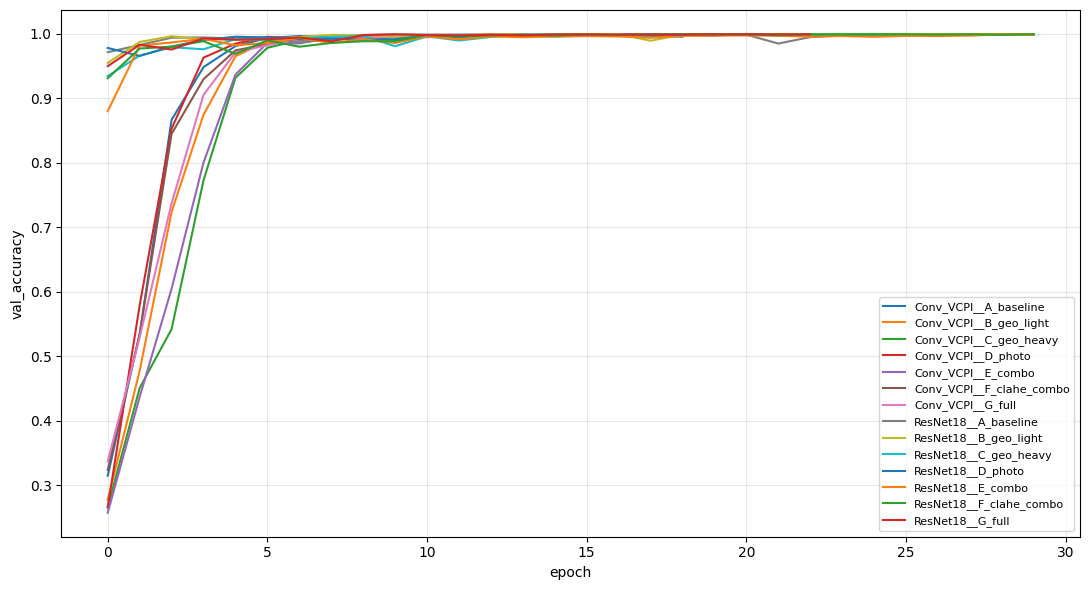

In [18]:
fig, ax = plt.subplots(figsize=(11, 6))
for r in all_results.values():
    key = f"{r['arch']}__{r['strategy']}"
    ax.plot(r['history']['val_accuracy'], label=key)
ax.set_xlabel('epoch')
ax.set_ylabel('val_accuracy')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Comparação Conv_VCPI vs ResNet18.

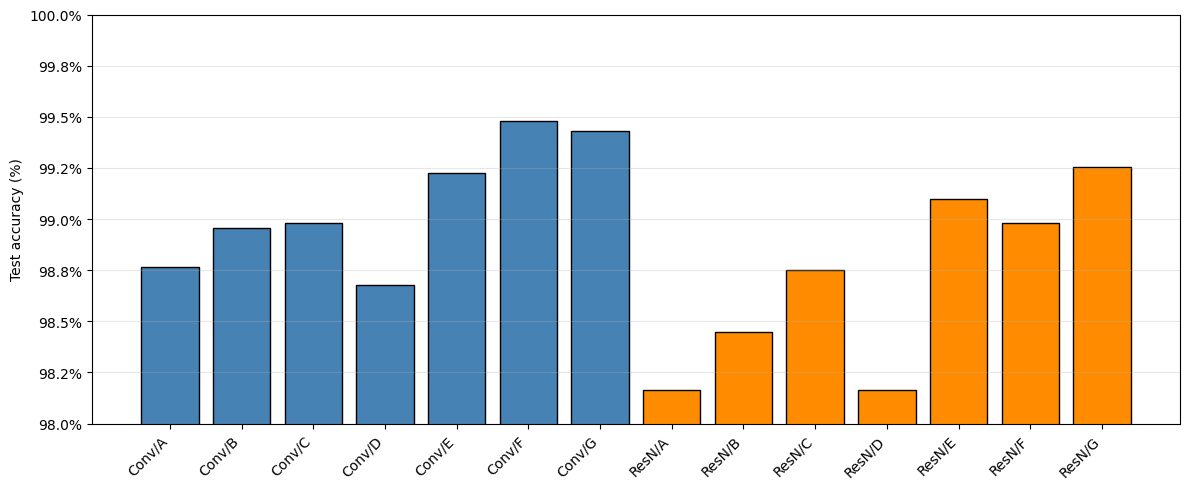

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
df_sorted = df.sort_values(['arch', 'estratégia'])
labels = [f'{a[:4]}/{s.split("_")[0]}' for a, s in zip(df_sorted['arch'], df_sorted['estratégia'])]
colors = ['steelblue' if a == 'Conv_VCPI' else 'darkorange' for a in df_sorted['arch']]
ax.bar(range(len(df_sorted)), df_sorted['test_acc'] * 100, color=colors, edgecolor='k')
ax.set_xticks(range(len(df_sorted)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Test accuracy (%)')
# escala ajustada para tornar as diferenças visíveis (todos os modelos ficam entre 98 e 100 %)
ax.set_ylim(98, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

Foi um resultado que não estava à espera: o Conv_VCPI bate o ResNet18 pretrained nas 7 estratégias, apesar de ter cerca de 33× menos parâmetros (332 k vs 11 M).

Algumas hipóteses para o que pode ter acontecido:

- As features do ResNet18 foram aprendidas em imagens 224×224. Ao usar 48×48 perdemos boa parte do benefício do *pretrain*.
- Os pictogramas dos sinais de trânsito têm pouca semelhança visual com o ImageNet, o que torna o *transfer learning* menos eficaz.
- Com ~33 mil imagens de treino, um modelo com 11 M parâmetros pode ter capacidade a mais.

Diagnóstico do melhor modelo — *train* vs *val*.

Melhor: Conv_VCPI__F_clahe_combo — test_acc=0.9948


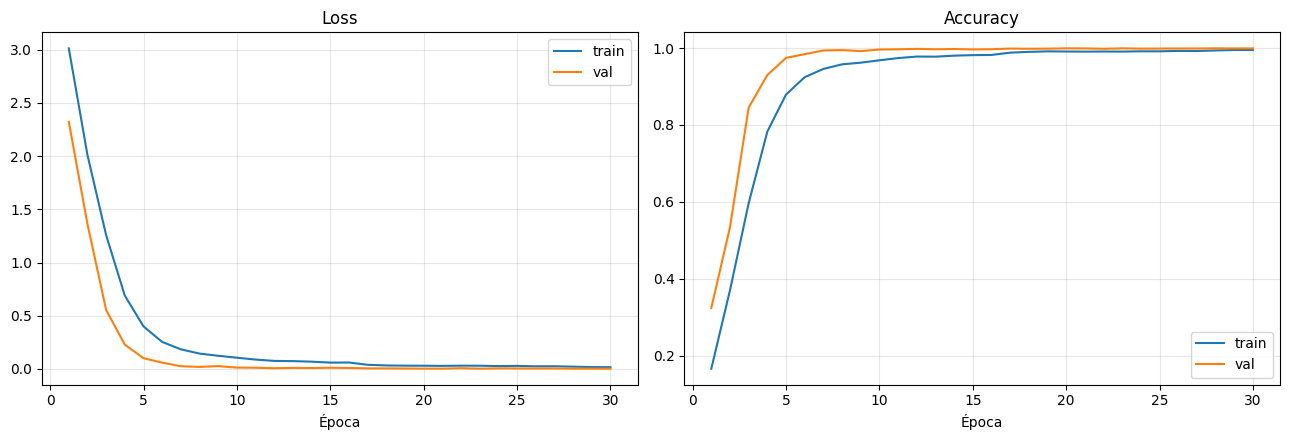

In [20]:
best_key   = df.iloc[0]['arch'] + '__' + df.iloc[0]['estratégia']
best_arch  = df.iloc[0]['arch']
best_strat = df.iloc[0]['estratégia']
print(f'Melhor: {best_key} — test_acc={df.iloc[0]["test_acc"]:.4f}')

h = all_results[best_key]['history']
eps = range(1, len(h['loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(eps, h['loss'],     label='train')
axes[0].plot(eps, h['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Época'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(eps, h['accuracy'],     label='train')
axes[1].plot(eps, h['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Época'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Curvas individuais de **todos os 14 modelos**, ordenados de melhor para pior (`test_acc` ↓).

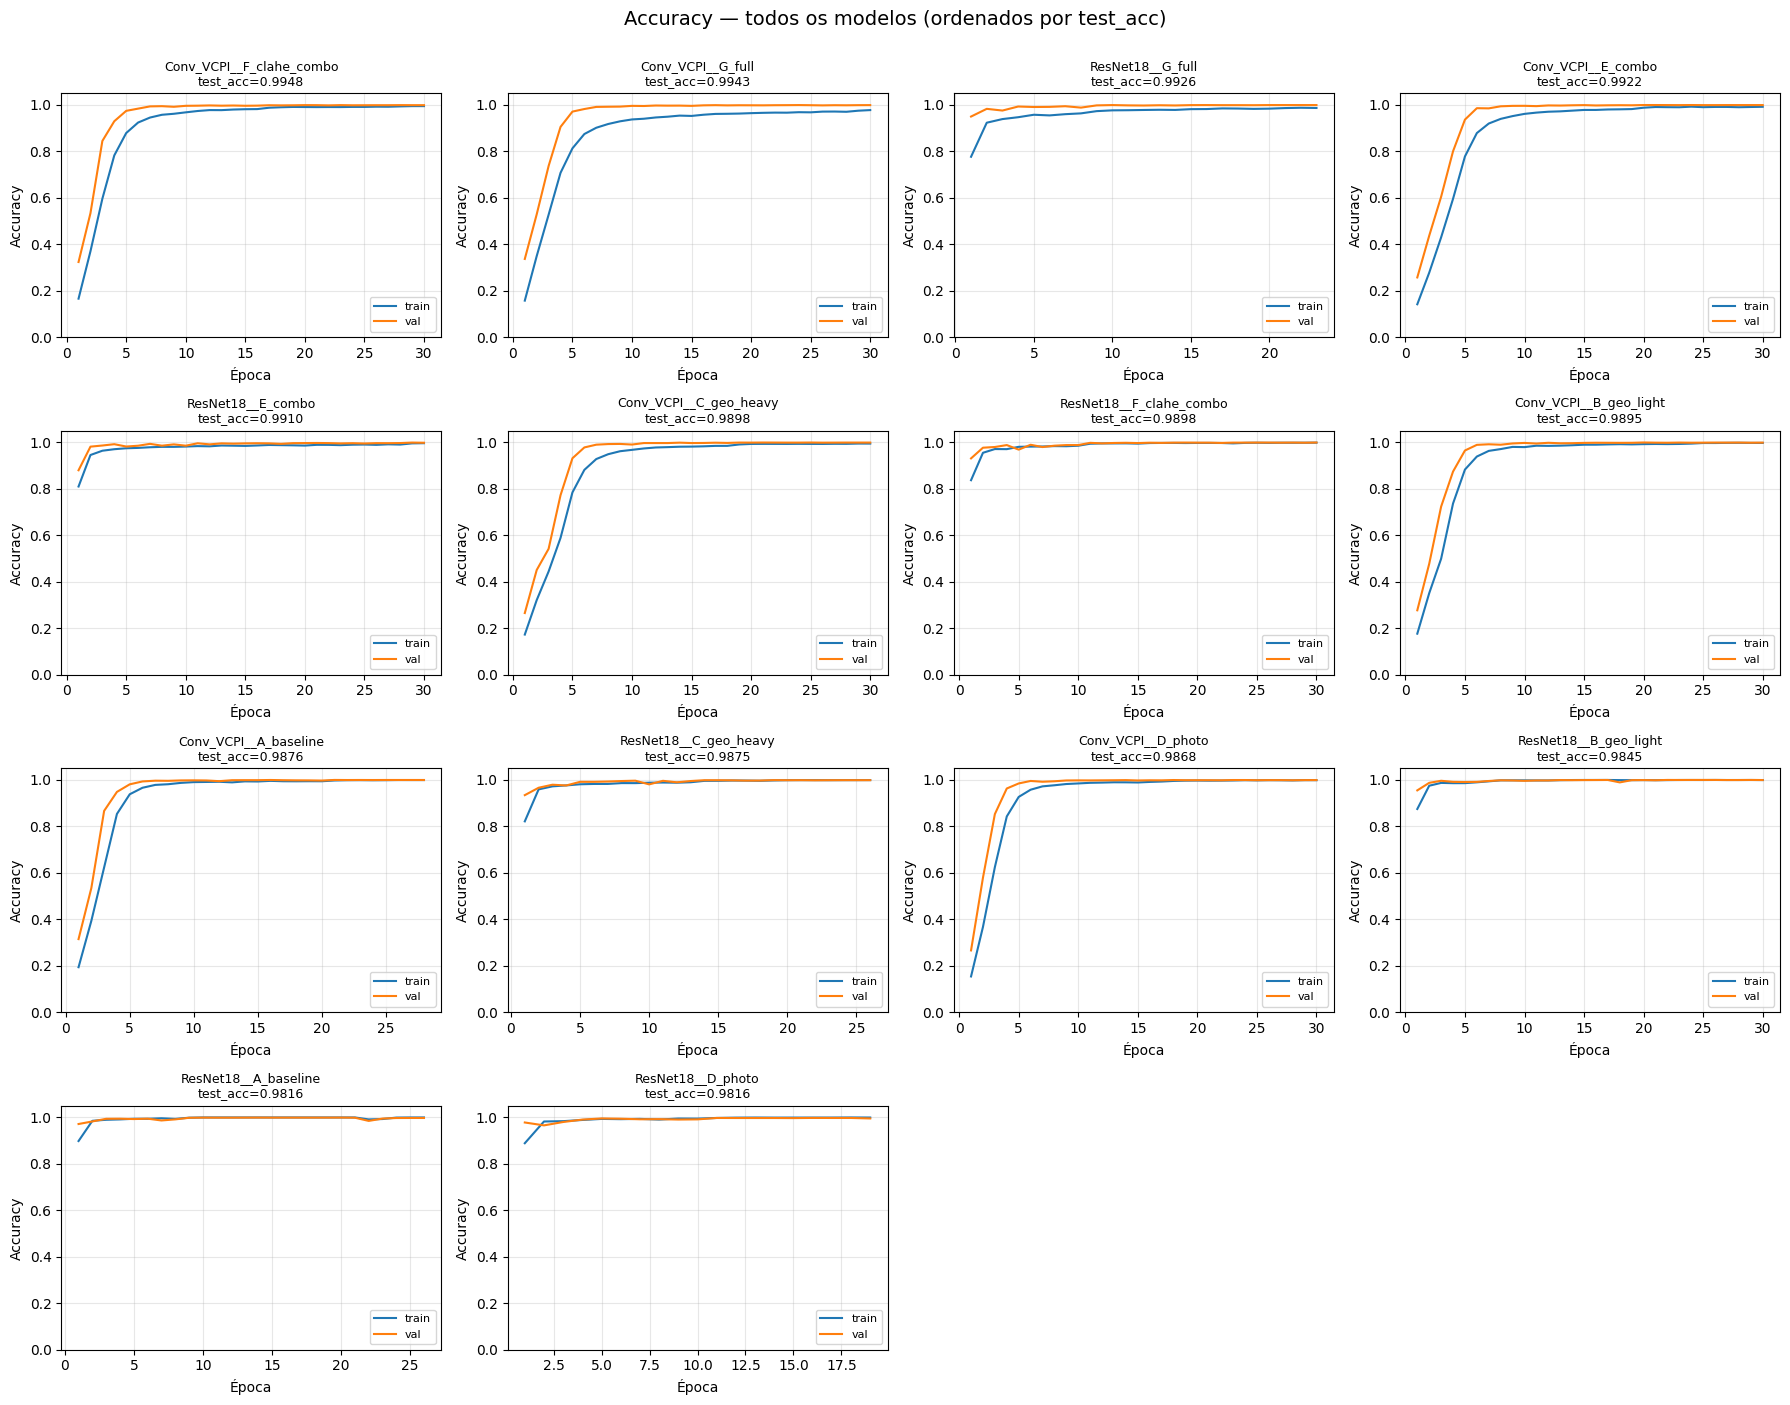

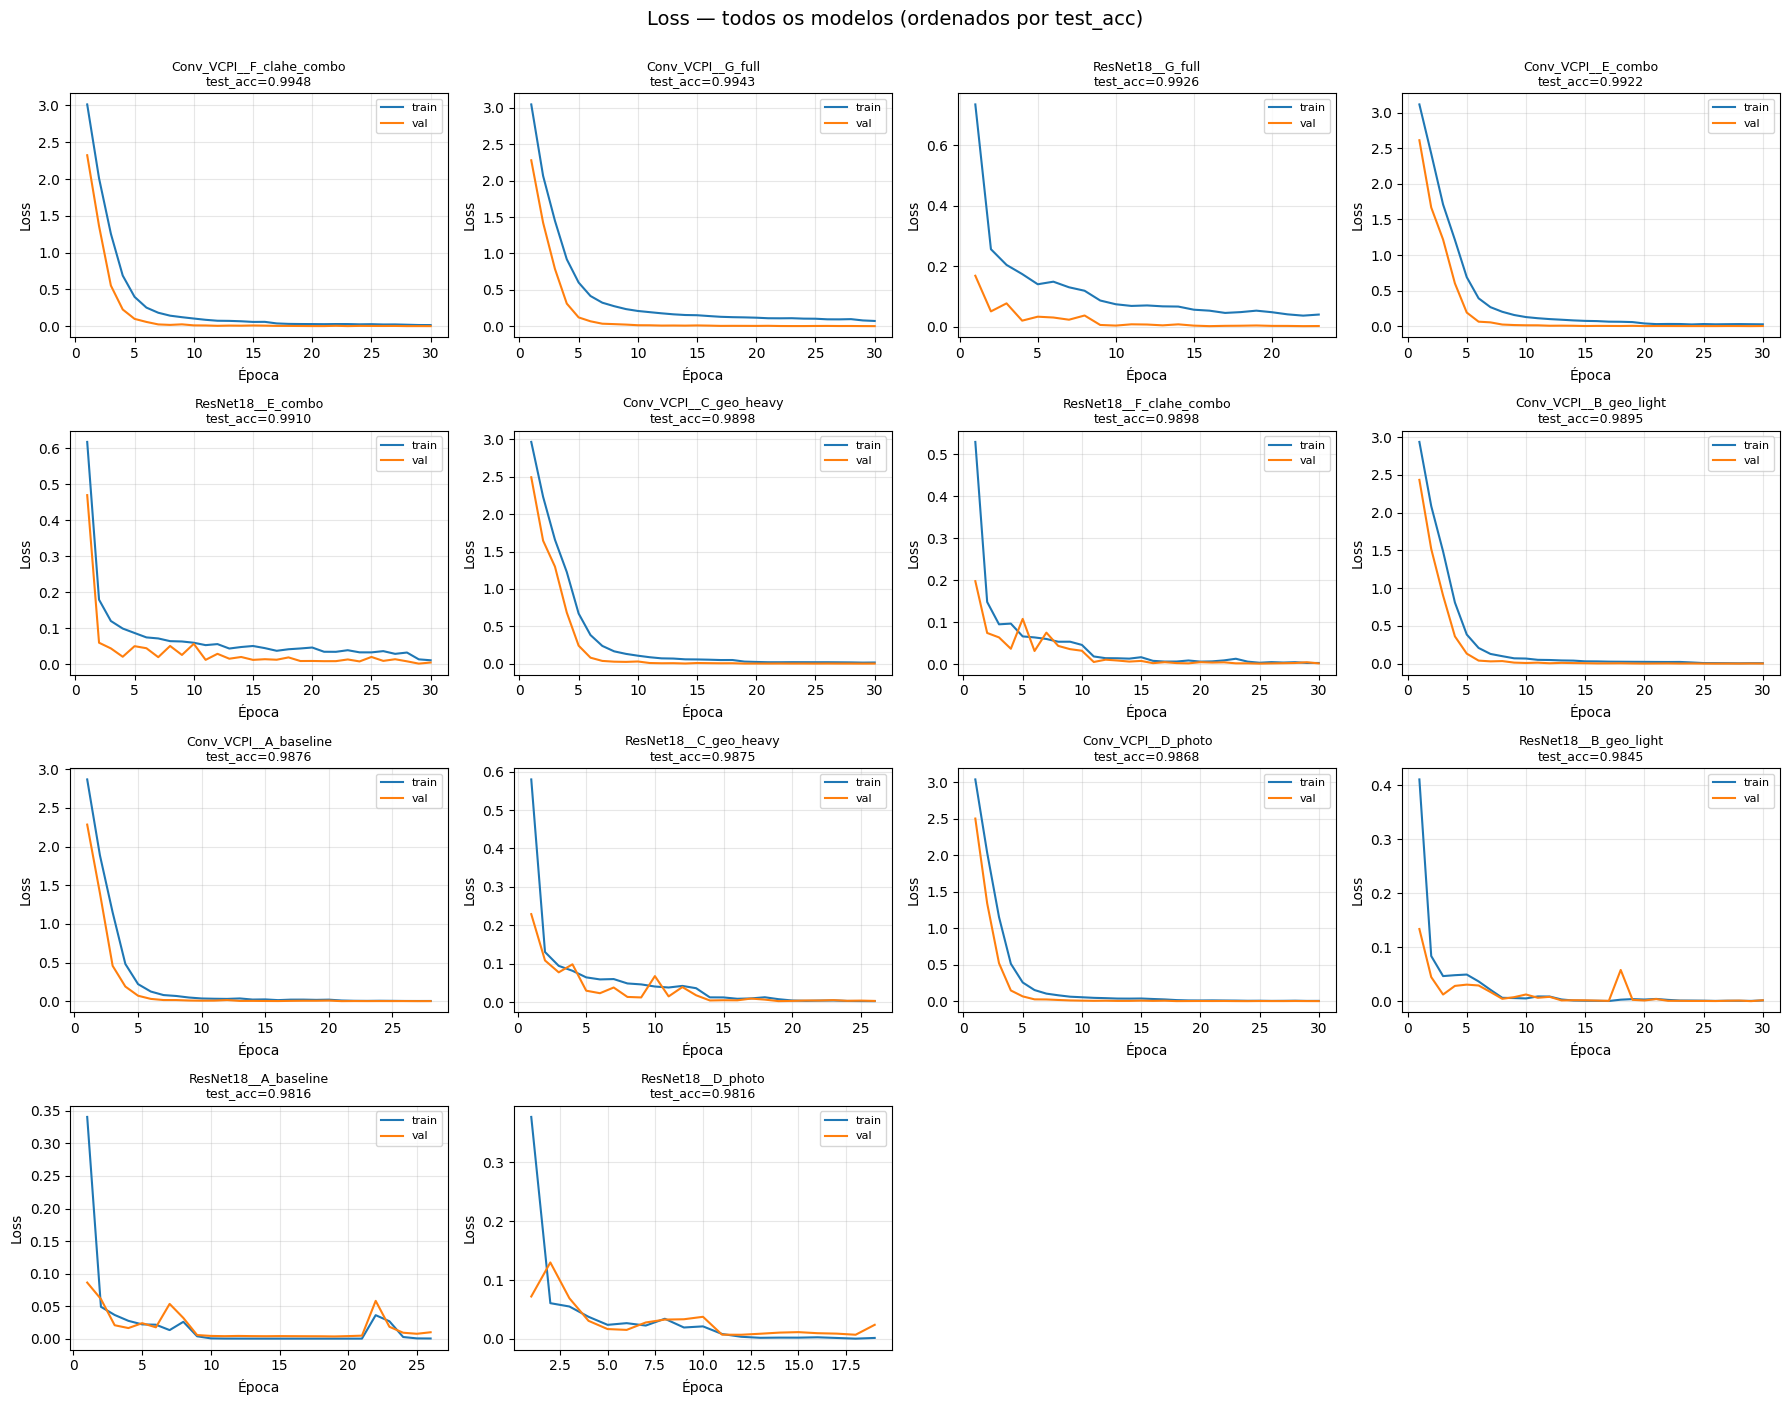

In [21]:
order = df.sort_values('test_acc', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, (_, row) in zip(axes.flat, order.iterrows()):
    key = f"{row['arch']}__{row['estratégia']}"
    h = all_results[key]['history']
    eps = range(1, len(h['accuracy']) + 1)
    ax.plot(eps, h['accuracy'],     label='train', linewidth=1.5)
    ax.plot(eps, h['val_accuracy'], label='val',   linewidth=1.5)
    ax.set_title(f"{key}\ntest_acc={row['test_acc']:.4f}", fontsize=9)
    ax.set_xlabel('Época'); ax.set_ylabel('Accuracy')
    ax.set_ylim(0.0, 1.05)
    ax.legend(fontsize=8, loc='lower right'); ax.grid(alpha=0.3)
for j in range(len(order), len(axes.flat)):
    axes.flat[j].axis('off')
plt.suptitle('Accuracy — todos os modelos (ordenados por test_acc)', fontsize=14, y=1.00)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, (_, row) in zip(axes.flat, order.iterrows()):
    key = f"{row['arch']}__{row['estratégia']}"
    h = all_results[key]['history']
    eps = range(1, len(h['loss']) + 1)
    ax.plot(eps, h['loss'],     label='train', linewidth=1.5)
    ax.plot(eps, h['val_loss'], label='val',   linewidth=1.5)
    ax.set_title(f"{key}\ntest_acc={row['test_acc']:.4f}", fontsize=9)
    ax.set_xlabel('Época'); ax.set_ylabel('Loss')
    ax.legend(fontsize=8, loc='upper right'); ax.grid(alpha=0.3)
for j in range(len(order), len(axes.flat)):
    axes.flat[j].axis('off')
plt.suptitle('Loss — todos os modelos (ordenados por test_acc)', fontsize=14, y=1.00)
plt.tight_layout(); plt.show()

Matriz de confusão e análise dos erros mais frequentes.

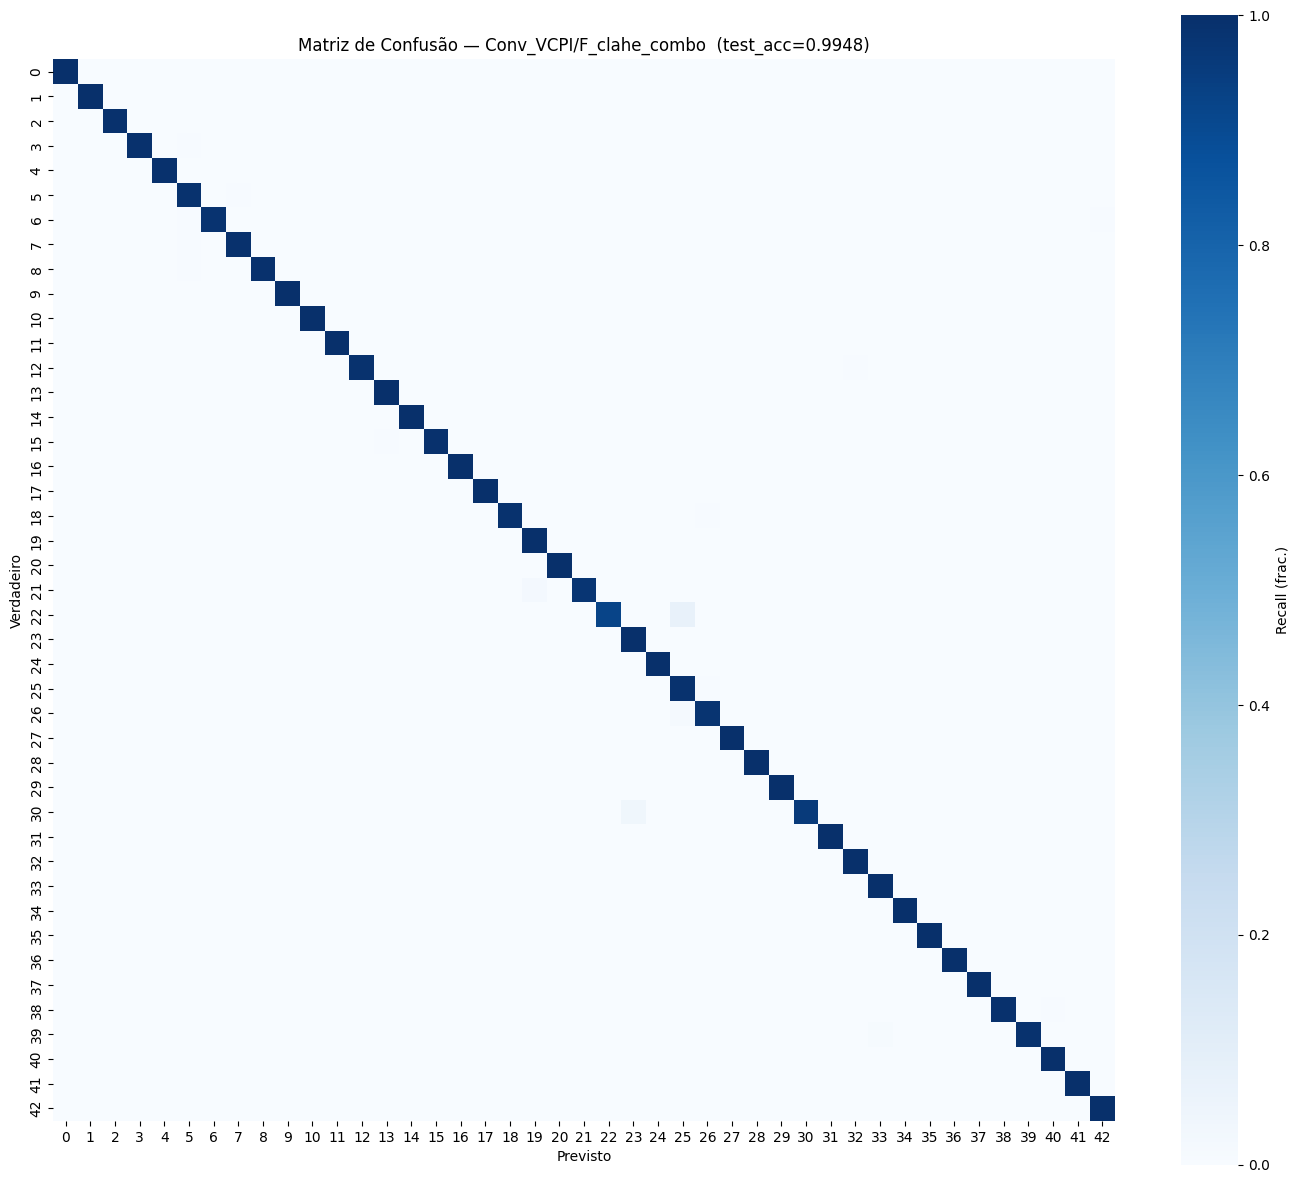

Top 10 confusões (verdadeiro → previsto):
  Pavim. irreg.          -> Obras                   : 9 (7.5%)
  Gelo/neve              -> Pavim. esc.             : 6 (4.0%)
  Via prioritária        -> Fim restrições          : 4 (0.6%)
  Semáforos              -> Obras                   : 3 (1.7%)
  Perigo geral           -> Semáforos               : 3 (0.8%)
  Mant. dir.             -> Rotunda                 : 3 (0.4%)
  Limite 80              -> Limite 100              : 3 (0.5%)
  Limite 60              -> Limite 80               : 3 (0.7%)
  Obras                  -> Semáforos               : 2 (0.4%)
  Curva dupla            -> Curva esq.              : 2 (2.2%)

5 classes pior classificadas:
  Pavim. irreg.            : 92.50%  (suporte: 120)
  Gelo/neve                : 96.00%  (suporte: 150)
  Curva dupla              : 97.78%  (suporte: 90)
  Semáforos                : 98.33%  (suporte: 180)
  Fim Limite 80            : 98.67%  (suporte: 150)


In [22]:
best_factory = get_conv_vcpi if best_arch == 'Conv_VCPI' else get_resnet18
best_model = best_factory().to(device)
best_model.load_state_dict(torch.load(CKPT_DIR / best_arch / best_strat / 'best.pt', weights_only=False)['model'])

_, _, test_loader = build_loaders(best_strat)
gt, preds, _ = predict(best_model, test_loader)
test_acc = (np.array(gt) == np.array(preds)).mean()

cm = confusion_matrix(gt, preds, labels=list(range(NUM_CLASSES)))
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_norm, cmap='Blues', square=True, annot=False,
            xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES),
            cbar_kws={'label': 'Recall (frac.)'}, ax=ax)
ax.set_xlabel('Previsto'); ax.set_ylabel('Verdadeiro')
ax.set_title(f'Matriz de Confusão — {best_arch}/{best_strat}  (test_acc={test_acc:.4f})')
plt.tight_layout(); plt.show()

cm_off = cm.copy(); np.fill_diagonal(cm_off, 0)
flat = np.argsort(cm_off.flatten())[::-1][:10]
print('Top 10 confusões (verdadeiro → previsto):')
for idx in flat:
    t, p = idx // NUM_CLASSES, idx % NUM_CLASSES
    n = cm_off[t, p]
    if n > 0:
        print(f'  {GTSRB_CLASS_NAMES[t]:22s} -> {GTSRB_CLASS_NAMES[p]:22s}  : {n} ({cm_norm[t, p]*100:.1f}%)')

per_class_acc = np.diag(cm) / cm.sum(axis=1)
worst = np.argsort(per_class_acc)[:5]
print('\n5 classes pior classificadas:')
for c in worst:
    print(f'  {GTSRB_CLASS_NAMES[c]:25s}: {per_class_acc[c]*100:.2f}%  (suporte: {cm[c].sum()})')

Galeria dos 16 erros mais confiantes — casos em que o modelo errou apesar de estar muito certo.

Total de erros: 66 / 12630  (accuracy = 99.48%)


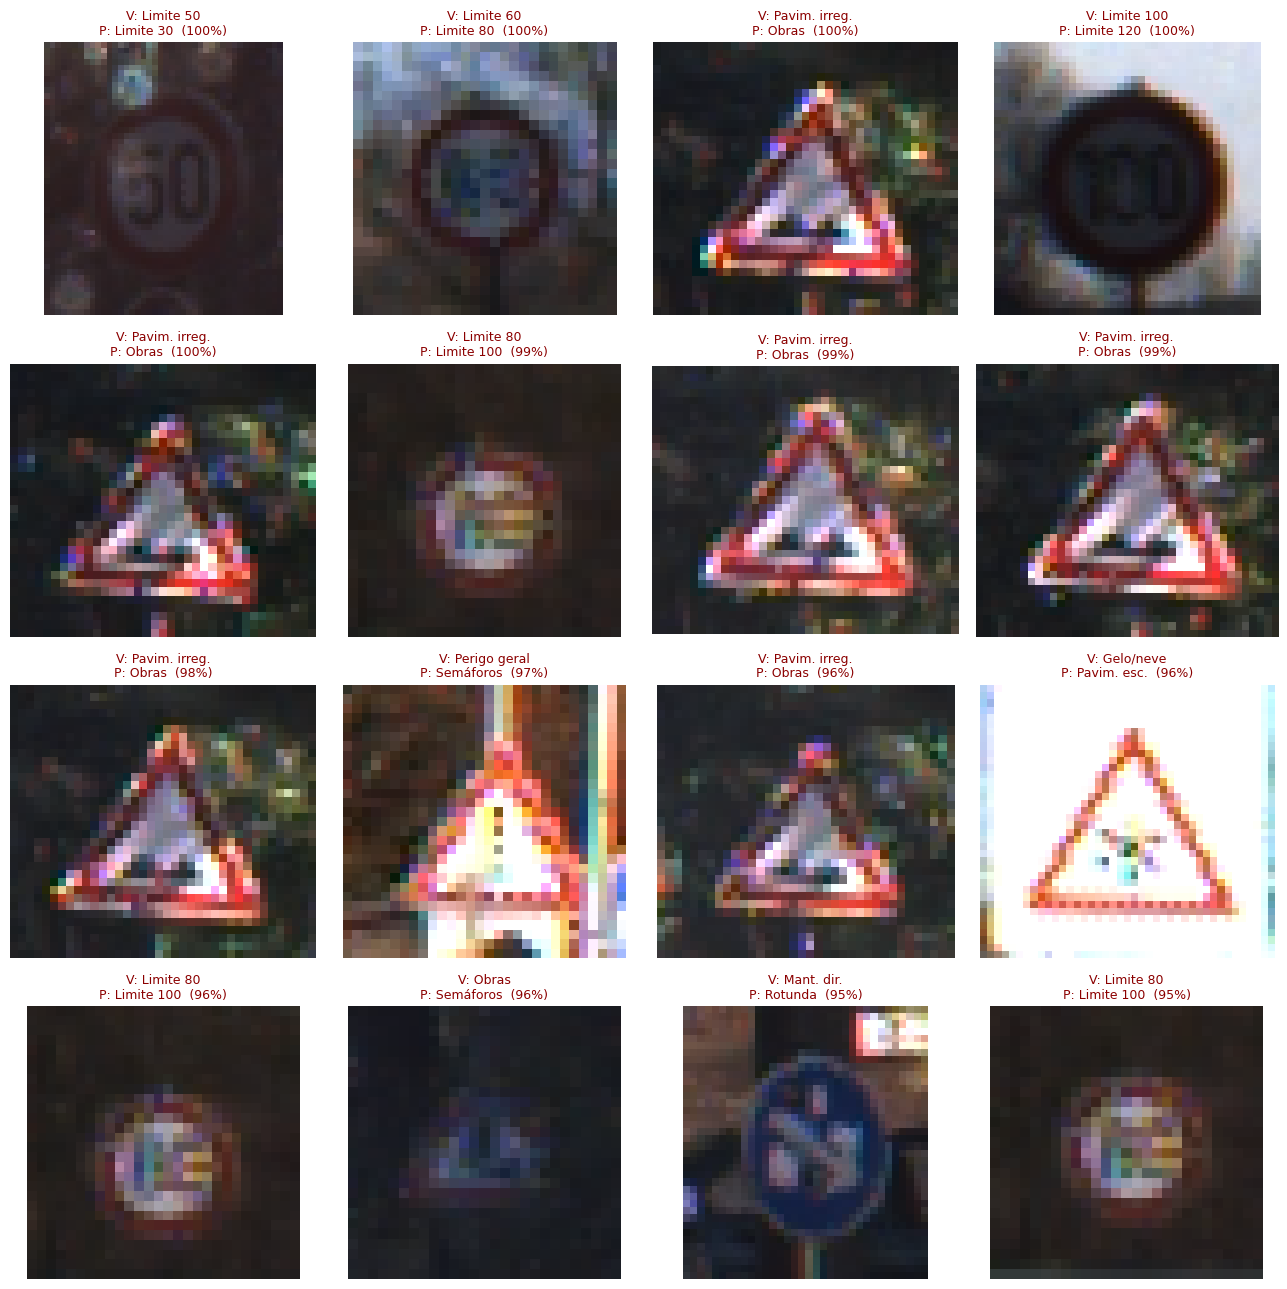

In [23]:
@torch.no_grad()
def predict_with_probs(model, loader):
    model.eval()
    all_lbl, all_pred, all_conf = [], [], []
    for imgs, lbls in loader:
        imgs = imgs.to(device, non_blocking=True)
        probs = F.softmax(model(imgs), dim=1)
        confs, preds = probs.max(dim=1)
        all_lbl.extend(lbls.tolist())
        all_pred.extend(preds.cpu().tolist())
        all_conf.extend(confs.cpu().tolist())
    return all_lbl, all_pred, all_conf

gt, preds, confs = predict_with_probs(best_model, test_loader)
wrong_idx = [i for i in range(len(gt)) if gt[i] != preds[i]]
wrong_idx.sort(key=lambda i: -confs[i])

test_samples = datasets.ImageFolder(root=str(TEST_DIR)).samples

print(f'Total de erros: {len(wrong_idx)} / {len(gt)}  (accuracy = {100*(1-len(wrong_idx)/len(gt)):.2f}%)')

fig, axes = plt.subplots(4, 4, figsize=(13, 13))
for ax, idx in zip(axes.flat, wrong_idx[:16]):
    path, _ = test_samples[idx]
    img = Image.open(path).convert('RGB')
    ax.imshow(img)
    ax.set_title(f'V: {GTSRB_CLASS_NAMES[gt[idx]]}\nP: {GTSRB_CLASS_NAMES[preds[idx]]}  ({confs[idx]*100:.0f}%)',
                 fontsize=9, color='darkred')
    ax.axis('off')
plt.tight_layout(); plt.show()

Padrões que se vêem nos erros do melhor modelo:

1. **Sinais triangulares de aviso confundem-se entre si.** Têm todos a mesma forma (triângulo branco com borda vermelha) e só mudam no pictograma interno. A 48×48 alguns pictogramas ficam quase indistinguíveis. Os casos mais frequentes foram Pavim. irreg. ↔ Obras e Gelo/neve ↔ Pavim. esc.

2. **Limites de velocidade adjacentes** (80 vs 100, 60 vs 80) também aparecem, mas com error rate muito baixo (<1 %).

3. **Classes minoritárias sofrem mais.** Pavim. irreg., a classe com menos imagens no teste (120), tem a pior accuracy (92.5 %).

Olhando para as 16 imagens com erro mais confiante, a maior parte são imagens com qualidade degradada (oclusão, contraluz, blur) ou sinais visualmente ambíguos à resolução escolhida. Casos onde mesmo uma pessoa teria dificuldade em decidir. Acho que o modelo está perto do limite do que se consegue com estes dados.

## Ablação adicional — `WeightedRandomSampler`

O dataset é bastante desbalanceado (rácio máximo/mínimo ~10×). Para perceber se o balanceamento por amostragem ajudaria, voltei a treinar a melhor configuração (`Conv_VCPI + F_clahe_combo`), desta vez com `WeightedRandomSampler` ativo. Com este sampler, cada classe passa a ter probabilidade aproximadamente igual de ser amostrada durante o treino.

Em seguida comparo a *per-class accuracy* das classes mais raras (que são as mais sensíveis a este tipo de intervenção).

In [24]:
ckpt_w = CKPT_DIR / 'Conv_VCPI' / 'F_clahe_combo_weighted' / 'best.pt'
log_w  = LOG_DIR / 'Conv_VCPI__F_clahe_combo_weighted.json'
if ckpt_w.exists() and log_w.exists():
    with open(log_w) as f:
        res_w = json.load(f)
    print(f"[skip] Conv_VCPI__F_clahe_combo_weighted (test_acc={res_w['test_acc']:.4f})")
else:
    res_w = train_model(get_conv_vcpi, 'F_clahe_combo', 'Conv_VCPI',
                        epochs=30, use_weighted_sampler=True)

[skip] Conv_VCPI__F_clahe_combo_weighted (test_acc=0.9936)


Comparação per-class das classes mais sensíveis ao desbalanceamento.

In [25]:
# Carregar o melhor modelo SEM sampler (ja treinado)
model_no = get_conv_vcpi().to(device)
model_no.load_state_dict(torch.load(
    CKPT_DIR / 'Conv_VCPI' / 'F_clahe_combo' / 'best.pt', weights_only=False)['model'])

# Carregar modelo COM sampler (acabado de treinar)
model_w = get_conv_vcpi().to(device)
model_w.load_state_dict(torch.load(
    CKPT_DIR / 'Conv_VCPI' / 'F_clahe_combo_weighted' / 'best.pt', weights_only=False)['model'])

_, _, test_loader = build_loaders('F_clahe_combo')
gt_no, preds_no, _ = predict(model_no, test_loader)
gt_w,  preds_w,  _ = predict(model_w,  test_loader)

# Per-class accuracy de ambos
cm_no = confusion_matrix(gt_no, preds_no, labels=list(range(NUM_CLASSES)))
cm_w  = confusion_matrix(gt_w,  preds_w,  labels=list(range(NUM_CLASSES)))
acc_no = np.diag(cm_no) / cm_no.sum(axis=1)
acc_w  = np.diag(cm_w)  / cm_w.sum(axis=1)

# Top-10 classes mais raras (suporte no teste)
support = cm_no.sum(axis=1)
rare = np.argsort(support)[:10]

print(f'Test acc geral: sem sampler={acc_no.mean()*100:.2f}% | com sampler={acc_w.mean()*100:.2f}%')
print(f'10 classes mais raras (per-class accuracy):')
print(f"{'Classe':<25} {'Suporte':>8} {'Sem':>8} {'Com':>8} {'Delta':>8}")
for c in rare:
    print(f'{GTSRB_CLASS_NAMES[c]:<25} {support[c]:>8d} '
          f'{acc_no[c]*100:>7.2f}% {acc_w[c]*100:>7.2f}% '
          f'{(acc_w[c]-acc_no[c])*100:>+7.2f}pp')

Test acc geral: sem sampler=99.40% | com sampler=99.28%
10 classes mais raras (per-class accuracy):
Classe                     Suporte      Sem      Com    Delta
Limite 20                       60  100.00%  100.00%   +0.00pp
Curva esq.                      60  100.00%  100.00%   +0.00pp
Peões                           60  100.00%  100.00%   +0.00pp
Fim restrições                  60  100.00%  100.00%   +0.00pp
Frente/esq.                     60  100.00%  100.00%   +0.00pp
Fim Proib.Ult.                  60  100.00%  100.00%   +0.00pp
Curva dir.                      90  100.00%  100.00%   +0.00pp
Curva dupla                     90   97.78%   93.33%   -4.44pp
Mant. esq.                      90   98.89%  100.00%   +1.11pp
Estreitam. dir.                 90  100.00%   98.89%   -1.11pp


O `WeightedRandomSampler` não melhorou — até piorou um pouco:

- Test acc global: 99.40 % sem sampler → 99.28 % com sampler (Δ = −0.12 pp)
- Das 10 classes mais raras, 7 já estavam em 100 % sem o sampler (não havia margem para melhorar). Das 3 que mudaram, só *Mant. esq.* melhorou (+1.11 pp). *Curva dupla* foi a que mais sofreu — caiu de 97.78 % para 93.33 % (−4.44 pp).

A minha leitura é que o sampler faz sentido quando o modelo está a colapsar para a classe maioritária. Aqui isso não acontece — a combinação `augmentation + BatchNorm + Dropout` já dá robustez suficiente às classes raras. Mostrar uma classe minoritária muitas vezes durante o treino acabou por levar a *overfitting* (especialmente em *Curva dupla*, que só tem 90 imagens no teste).

Para datasets com desbalanceamento mais extremo ou modelos mais simples o sampler continua a fazer sentido. Neste pipeline em particular, decidi não o usar.

## Ablação adicional — resolução de entrada (48×48 vs 64×64)

Para testar se uma resolução maior melhoraria a accuracy, voltei a treinar a melhor configuração (`Conv_VCPI + F_clahe_combo`) com imagens redimensionadas para 64×64 em vez de 48×48.

A minha expectativa era um ganho pequeno (0.1–0.3 pp), porque a maioria das imagens originais é pequena (mediana ~40 px). Aumentar para 64×64 envolve sobretudo *upsampling* (interpolação), que não acrescenta detalhe real.

In [26]:
# === Ablação a 64x64 ===
IMG_SIZE_64 = 64

# Transforms equivalentes a F_clahe_combo mas com novo tamanho
TO_T = [v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]
NORM = v2.Normalize(mean=DATASET_MEAN, std=DATASET_STD)   # mean/std do treino (estatísticas por canal são aproximadamente invariantes ao resize)

tfm_64_train = v2.Compose([
    CLAHETransform(p=1.0),
    v2.Resize((IMG_SIZE_64, IMG_SIZE_64)),
    v2.RandomAffine(degrees=15, translate=[0.1, 0.1], scale=(0.85, 1.15), shear=10),
    v2.RandomPerspective(distortion_scale=0.2, p=0.5),
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    *TO_T, NORM,
])
tfm_64_eval = v2.Compose([
    CLAHETransform(p=1.0),
    v2.Resize((IMG_SIZE_64, IMG_SIZE_64)),
    *TO_T, NORM,
])

tr_full_64 = datasets.ImageFolder(root=str(TRAIN_DIR), transform=tfm_64_train)
va_full_64 = datasets.ImageFolder(root=str(TRAIN_DIR), transform=tfm_64_eval)
te_set_64  = datasets.ImageFolder(root=str(TEST_DIR),  transform=tfm_64_eval)

pin = (device.type == 'cuda')
tr_loader_64 = DataLoader(Subset(tr_full_64, train_idx), batch_size=BATCH_SIZE, shuffle=True, pin_memory=pin)
va_loader_64 = DataLoader(Subset(va_full_64, val_idx),   batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin)
te_loader_64 = DataLoader(te_set_64, batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin)

# Treino (reutilizando train_one_epoch e evaluate)
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
model_64 = get_conv_vcpi().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_64.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)
scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None

save_path_64 = CKPT_DIR / 'Conv_VCPI' / 'F_clahe_combo_64'
save_path_64.mkdir(parents=True, exist_ok=True)
best_ckpt_64 = save_path_64 / 'best.pt'

history_64 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
best_val_loss_64, no_improve = float('inf'), 0
t_start = time.time()

if best_ckpt_64.exists():
    print(f'[skip] best_ckpt já existe')
    model_64.load_state_dict(torch.load(best_ckpt_64, weights_only=False)['model'])
else:
    for epoch in range(1, 31):
        tr_loss, tr_acc = train_one_epoch(model_64, tr_loader_64, criterion, optimizer, scaler)
        va_loss, va_acc = evaluate(model_64, va_loader_64, criterion)
        scheduler.step(va_loss)
        history_64['loss'].append(tr_loss); history_64['accuracy'].append(tr_acc)
        history_64['val_loss'].append(va_loss); history_64['val_accuracy'].append(va_acc)
        print(f'  [{epoch:02d}/30] loss={tr_loss:.4f} acc={tr_acc:.4f}  val_loss={va_loss:.4f} val_acc={va_acc:.4f}')
        if va_loss < best_val_loss_64:
            best_val_loss_64, no_improve = va_loss, 0
            torch.save({'model': model_64.state_dict(), 'val_loss': va_loss, 'val_acc': va_acc}, best_ckpt_64)
        else:
            no_improve += 1
            if no_improve >= 7:
                print(f'early stop @ epoch {epoch}')
                break
    model_64.load_state_dict(torch.load(best_ckpt_64, weights_only=False)['model'])

test_loss_64, test_acc_64 = evaluate(model_64, te_loader_64, criterion)
print(f'=== Resultados ===')
print(f'  48×48 (já treinado): test_acc = 0.9948')
print(f'  64×64 (este treino): test_acc = {test_acc_64:.4f}')
print(f'  Delta              : {(test_acc_64-0.9948)*100:+.2f} pp')

[skip] best_ckpt já existe
=== Resultados ===
  48×48 (já treinado): test_acc = 0.9948
  64×64 (este treino): test_acc = 0.9938
  Delta              : -0.10 pp


A 64×64 ficou ligeiramente pior que a 48×48 (−0.10 pp) e demorou cerca do dobro do tempo (40 min vs ~20 min).

A diferença está dentro da margem de ruído (±0.1 pp neste regime), por isso não acho que dê para afirmar que 64×64 é mesmo pior — só que claramente não compensa.

Faz sentido: a mediana das imagens originais do GTSRB anda nos ~40 px. Ao redimensionar para 64×64 estamos sobretudo a fazer *upsampling* (interpolação bilinear), que não acrescenta detalhe real. Os erros que vimos na matriz de confusão são sobretudo (i) imagens com má qualidade ou (ii) ambiguidades entre sinais semelhantes — coisas que mais pixels não resolvem.

Conclusão: 48×48 é uma boa escolha para este dataset.

## Ablação adicional — resolução nativa do ResNet18 (224×224)

A ResNet18 foi pretrained no ImageNet a 224×224. Faz sentido testar se subir a resolução de input para 224 (a "nativa" do modelo) compensa o custo computacional.

A minha expectativa é ganho marginal — a maioria das imagens originais é pequena (mediana ~40 px), por isso 224×224 envolve sobretudo *upsampling massivo* (~5.6×). A ablação a 64×64 já mostrou que aumentar a resolução não ajuda neste dataset; o 224 deve amplificar essa tendência. Vamos confirmar.

**Nota:** uso `batch_size=64` (em vez de 128) para evitar *out of memory* a 224×224.

In [ ]:
# === Ablação a 224×224 com ResNet18 ===
IMG_SIZE_224 = 224
BATCH_SIZE_224 = 64   # menor para caber em memória GPU

tfm_224_train = v2.Compose([
    CLAHETransform(p=1.0),
    v2.Resize((IMG_SIZE_224, IMG_SIZE_224)),
    v2.RandomAffine(degrees=15, translate=[0.1, 0.1], scale=(0.85, 1.15), shear=10),
    v2.RandomPerspective(distortion_scale=0.2, p=0.5),
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=DATASET_MEAN, std=DATASET_STD),
])
tfm_224_eval = v2.Compose([
    CLAHETransform(p=1.0),
    v2.Resize((IMG_SIZE_224, IMG_SIZE_224)),
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=DATASET_MEAN, std=DATASET_STD),
])

tr_full_224 = datasets.ImageFolder(root=str(TRAIN_DIR), transform=tfm_224_train)
va_full_224 = datasets.ImageFolder(root=str(TRAIN_DIR), transform=tfm_224_eval)
te_set_224  = datasets.ImageFolder(root=str(TEST_DIR),  transform=tfm_224_eval)

pin = (device.type == 'cuda')
tr_loader_224 = DataLoader(Subset(tr_full_224, train_idx), batch_size=BATCH_SIZE_224, shuffle=True, pin_memory=pin)
va_loader_224 = DataLoader(Subset(va_full_224, val_idx),   batch_size=BATCH_SIZE_224, shuffle=False, pin_memory=pin)
te_loader_224 = DataLoader(te_set_224, batch_size=BATCH_SIZE_224, shuffle=False, pin_memory=pin)

# Treino
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
model_224 = get_resnet18().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_224.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)
scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None

save_path_224 = CKPT_DIR / 'ResNet18' / 'F_clahe_combo_224'
save_path_224.mkdir(parents=True, exist_ok=True)
best_ckpt_224 = save_path_224 / 'best.pt'

if best_ckpt_224.exists():
    print(f'[skip] best_ckpt já existe — a carregar')
    model_224.load_state_dict(torch.load(best_ckpt_224, weights_only=False)['model'])
else:
    history_224 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_loss_224, no_improve = float('inf'), 0
    t_start = time.time()

    for epoch in range(1, 21):
        tr_loss, tr_acc = train_one_epoch(model_224, tr_loader_224, criterion, optimizer, scaler)
        va_loss, va_acc = evaluate(model_224, va_loader_224, criterion)
        scheduler.step(va_loss)
        history_224['loss'].append(tr_loss); history_224['accuracy'].append(tr_acc)
        history_224['val_loss'].append(va_loss); history_224['val_accuracy'].append(va_acc)
        print(f'  [{epoch:02d}/20] loss={tr_loss:.4f} acc={tr_acc:.4f}  val_loss={va_loss:.4f} val_acc={va_acc:.4f}')
        if va_loss < best_val_loss_224:
            best_val_loss_224, no_improve = va_loss, 0
            torch.save({'model': model_224.state_dict(), 'val_loss': va_loss, 'val_acc': va_acc}, best_ckpt_224)
        else:
            no_improve += 1
            if no_improve >= 7:
                print(f'early stop @ epoch {epoch}')
                break
    model_224.load_state_dict(torch.load(best_ckpt_224, weights_only=False)['model'])
    print(f'Tempo de treino: {(time.time()-t_start)/60:.1f} min')

test_loss_224, test_acc_224 = evaluate(model_224, te_loader_224, criterion)

# Guardar log JSON
# (NB: history_224 só existe se o treino correu nesta sessão; se foi skip, history fica vazia)
try:
    history_to_save = history_224
    epochs_run = len(history_224['loss'])
    elapsed_min = (time.time()-t_start)/60 if 't_start' in dir() else None
except NameError:
    history_to_save = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    epochs_run = None
    elapsed_min = None

result_224 = {
    'arch': 'ResNet18', 'strategy': 'F_clahe_combo_224',
    'test_acc': test_acc_224, 'test_loss': test_loss_224,
    'epochs_run': epochs_run,
    'time_min': elapsed_min,
    'ckpt_path': str(best_ckpt_224),
    'history': history_to_save,
    'note': 'Ablacao a 224x224 (vs 48x48 default), batch_size=64',
}
with open(LOG_DIR / 'ResNet18__F_clahe_combo_224.json', 'w') as f:
    json.dump(result_224, f, indent=2)

print(f'=== Resultados ResNet18 + F_clahe_combo ===')
print(f'  48×48   (já treinado): test_acc = 0.9898')
print(f'  224×224 (este treino): test_acc = {test_acc_224:.4f}')
print(f'  Delta                 : {(test_acc_224-0.9898)*100:+.2f} pp')

[skip] best_ckpt já existe — a carregar


**Interpretação do resultado:**

A expectativa estava errada. A 224×224 a ResNet18 chegou a **99.52 %** — não só recupera os ~0.5 pp que tinha de défice contra o Conv_VCPI a 48×48, como o **ultrapassa** e passa a ser o melhor modelo da Fase 1.

Comparação prática:
- **Conv_VCPI a 48×48** (melhor anterior): **99.48 %**.
- **ResNet18 a 48×48** (F_clahe_combo): 98.98 %.
- **ResNet18 a 224×224** (este teste): **99.52 %** — Δ = +0.54 pp vs 48×48, +0.04 pp vs Conv_VCPI.

Apesar do input a 224 ser maioritariamente *upsampling* (mediana original ~40 px), os pesos pretrained do ImageNet só passam a contribuir realmente nesta resolução: as features iniciais (bordas, texturas) foram aprendidas a esta escala e a 48×48 estão a ser usadas fora do regime para que foram treinadas. O ganho de qualidade compensa o input interpolado.

O custo computacional não foi tão dramático quanto se podia recear: **99.6 min vs ~39.5 min** do mesmo modelo a 48×48 (~2.5× o tempo, com `batch_size=64` em vez de 128).

**Conclusão revista.** Para tirar partido do *transfer learning* a partir do ImageNet é preciso aproximar a resolução de input à resolução nativa do modelo pretrained — caso contrário, o Conv_VCPI feito à medida do dataset é mais competitivo. Com a resolução certa, a ResNet18 passa à frente.

## Conclusões da Fase 1

Acabei a Fase 1 com **99.52 %** de test accuracy (`ResNet18 + F_clahe_combo` a 224×224), cerca de 0.30 pp abaixo do SOTA (*State of the Art*, melhor resultado publicado, ~99.82 %). O segundo melhor é o `Conv_VCPI + F_clahe_combo` a 48×48 com **99.48 %**.

Resumo do que aprendi com a 1ª fase deste trabalho:

1. **A resolução de input importa para transfer learning.** O ResNet18 a 48×48 ficava atrás do Conv_VCPI, mas a 224×224 (resolução nativa do pretrained ImageNet) inverte o resultado e passa a ser o melhor modelo da Fase 1. Os pesos pretrained só rendem perto da escala em que foram treinados.

2. **Para a resolução nativa do dataset (48×48), uma arquitetura à medida bate o ResNet18 pretrained.** O Conv_VCPI tem 33× menos parâmetros e mesmo assim é mais competitivo a 48×48. Reforça que *transfer learning* não é gratuito — depende muito do *match* de domínio/resolução.

3. **O CLAHE (*Contrast Limited Adaptive Histogram Equalization*) como pré-processamento trouxe um ganho real** (+0.26 pp comparando E com F no Conv_VCPI). Confirma que técnicas tradicionais de processamento de imagem ainda fazem diferença em *deep learning*.

4. **A combinação geo + foto + CLAHE é melhor que qualquer componente isolado.** A ordem aproximada de resultado é A < D ≈ B < C < E < F ≈ G.

5. **O `RandomErasing` (G) não trouxe melhoria** no Conv_VCPI. Quando a augmentation já é rica, parece ser regularização a mais.

6. **O `WeightedRandomSampler` também não compensou** (ablação extra). O modelo já generaliza bem para classes raras sem ajuda explícita — o desbalanceamento não é o gargalo neste pipeline.

7. **Os erros que sobram são quase todos por ambiguidade visual** (sinais triangulares parecidos, limites adjacentes, imagens degradadas). O modelo parece estar perto do tecto do que é alcançável sem técnicas mais agressivas (ensembles, TTA).

Sobre a resolução de entrada: para o Conv_VCPI testei 64×64 (−0.10 pp ao dobro do tempo) — 48×48 é o ponto certo para essa arquitetura, em que ~50 % das imagens originais têm menos de 48 px. Para o ResNet18, em compensação, **subir a 224×224 valeu a pena** (+0.54 pp a 2.5× o tempo).

Para a Fase 2 vou combinar os 15 *checkpoints* em ensembles (soft voting, weighted average, subset selection, possivelmente TTA — *Test Time Augmentation*, aplicar augmentation no teste e agregar as previsões), com o `ResNet18 @ 224` como peça central, para tentar puxar a accuracy um pouco mais.

---
# Fase 2 — Ensembles

Nesta fase combino as redes treinadas na Fase 1 num *ensemble*, para ver se melhoro a accuracy face ao melhor modelo individual.

O pool tem **17 modelos**: as 14 combinações principais (7 estratégias × 2 arquiteturas) mais 3 ablações (`Conv_VCPI` a 64×64, `Conv_VCPI` com WeightedSampler, e `ResNet18` a 224×224).

Reutilizo as arquiteturas e o `CLAHETransform` já definidos na Fase 1. Só preciso de funções novas para construir loaders de avaliação em qualquer tamanho (alguns modelos usam 48, outros 64 ou 224).

In [ ]:
# Loaders de avaliação flexíveis (qualquer tamanho), reutilizando o CLAHETransform da Fase 1
def make_eval_transform(img_size, use_clahe):
    ops = []
    if use_clahe:
        ops.append(CLAHETransform(p=1.0))
    ops += [v2.Resize((img_size, img_size)),
            v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(mean=DATASET_MEAN, std=DATASET_STD)]
    return v2.Compose(ops)

def make_test_loader(img_size, use_clahe):
    tfm = make_eval_transform(img_size, use_clahe)
    test_set = datasets.ImageFolder(root=str(TEST_DIR), transform=tfm)
    return DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False,
                      pin_memory=(device.type == 'cuda'))

## Registo dos 17 modelos

Para cada modelo guardo: nome, arquitetura, tamanho de imagem, se usa CLAHE, e o caminho do checkpoint.

In [ ]:
# (nome, factory, img_size, use_clahe, ckpt_path)
MODELS = []

CONV_STRATS = ['A_baseline','B_geo_light','C_geo_heavy','D_photo','E_combo','F_clahe_combo','G_full']
for s in CONV_STRATS:
    use_clahe = s in ('F_clahe_combo', 'G_full')
    MODELS.append((f'Conv_VCPI/{s}', get_conv_vcpi, 48, use_clahe,
                   CKPT_DIR / 'Conv_VCPI' / s / 'best.pt'))
for s in CONV_STRATS:
    use_clahe = s in ('F_clahe_combo', 'G_full')
    MODELS.append((f'ResNet18/{s}', get_resnet18, 48, use_clahe,
                   CKPT_DIR / 'ResNet18' / s / 'best.pt'))

# Ablações
MODELS.append(('Conv_VCPI/F_clahe_combo_64',       get_conv_vcpi, 64,  True,
               CKPT_DIR / 'Conv_VCPI' / 'F_clahe_combo_64' / 'best.pt'))
MODELS.append(('Conv_VCPI/F_clahe_combo_weighted', get_conv_vcpi, 48,  True,
               CKPT_DIR / 'Conv_VCPI' / 'F_clahe_combo_weighted' / 'best.pt'))
MODELS.append(('ResNet18/F_clahe_combo_224',       get_resnet18, 224, True,
               CKPT_DIR / 'ResNet18' / 'F_clahe_combo_224' / 'best.pt'))

# Manter só os que existem em disco
MODELS = [m for m in MODELS if m[4].exists()]
print(f'{len(MODELS)} modelos no pool:')
for name, _, sz, clahe, _ in MODELS:
    print(f'  {name:35s} {sz}x{sz}  CLAHE={clahe}')

17 modelos no pool:
  Conv_VCPI/A_baseline                48x48  CLAHE=False
  Conv_VCPI/B_geo_light               48x48  CLAHE=False
  Conv_VCPI/C_geo_heavy               48x48  CLAHE=False
  Conv_VCPI/D_photo                   48x48  CLAHE=False
  Conv_VCPI/E_combo                   48x48  CLAHE=False
  Conv_VCPI/F_clahe_combo             48x48  CLAHE=True
  Conv_VCPI/G_full                    48x48  CLAHE=True
  ResNet18/A_baseline                 48x48  CLAHE=False
  ResNet18/B_geo_light                48x48  CLAHE=False
  ResNet18/C_geo_heavy                48x48  CLAHE=False
  ResNet18/D_photo                    48x48  CLAHE=False
  ResNet18/E_combo                    48x48  CLAHE=False
  ResNet18/F_clahe_combo              48x48  CLAHE=True
  ResNet18/G_full                     48x48  CLAHE=True
  Conv_VCPI/F_clahe_combo_64          64x64  CLAHE=True
  Conv_VCPI/F_clahe_combo_weighted    48x48  CLAHE=True
  ResNet18/F_clahe_combo_224          224x224  CLAHE=True


## Calcular os logits de cada modelo no test set

Carrego cada modelo, passo o test set pelo seu pré-processamento e guardo os logits. Faço cache em disco (`logits_cache.pt`) para não ter de repetir a cada execução — calcular os 17 modelos (sobretudo o de 224×224) demora alguns minutos.

In [ ]:
@torch.no_grad()
def compute_logits(model, loader):
    model.eval()
    out, lbls = [], []
    for imgs, y in loader:
        imgs = imgs.to(device, non_blocking=True)
        out.append(model(imgs).cpu())
        lbls.append(y)
    return torch.cat(out), torch.cat(lbls)

CACHE = Path('logits_cache.pt')

if CACHE.exists():
    blob = torch.load(CACHE, weights_only=False)
    logits_by_model = blob['logits']
    y_true = blob['y_true']
    print(f'Logits carregados da cache ({len(logits_by_model)} modelos).')
else:
    logits_by_model = {}
    y_true = None
    for name, factory, img_size, use_clahe, ckpt in MODELS:
        t0 = time.time()
        model = factory().to(device)
        model.load_state_dict(torch.load(ckpt, weights_only=False)['model'])
        loader = make_test_loader(img_size, use_clahe)
        logits, lbls = compute_logits(model, loader)
        logits_by_model[name] = logits
        if y_true is None:
            y_true = lbls
        else:
            assert torch.equal(y_true, lbls), 'Ordem do test set difere!'
        acc = (logits.argmax(1) == lbls).float().mean().item()
        print(f'  {name:35s} acc={acc:.4f}  ({time.time()-t0:.1f}s)')
        del model
    torch.save({'logits': logits_by_model, 'y_true': y_true}, CACHE)
    print(f'\nGuardado em {CACHE}')

Logits carregados da cache (17 modelos).


## Accuracy individual de cada modelo (sanidade)

Confirmo que os valores batem com os da Fase 1. O `ResNet18` a 224×224 deve destacar-se — é a resolução para que a arquitetura foi desenhada.

In [ ]:
y = y_true.numpy()
rows = []
for name, logits in logits_by_model.items():
    acc = (logits.argmax(1).numpy() == y).mean()
    rows.append({'modelo': name, 'test_acc': acc})
df_ind = pd.DataFrame(rows).sort_values('test_acc', ascending=False).reset_index(drop=True)
print(df_ind.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

                          modelo  test_acc
      ResNet18/F_clahe_combo_224    0.9952
         Conv_VCPI/F_clahe_combo    0.9948
                Conv_VCPI/G_full    0.9943
      Conv_VCPI/F_clahe_combo_64    0.9938
Conv_VCPI/F_clahe_combo_weighted    0.9936
                 ResNet18/G_full    0.9926
               Conv_VCPI/E_combo    0.9922
                ResNet18/E_combo    0.9910
           Conv_VCPI/C_geo_heavy    0.9898
          ResNet18/F_clahe_combo    0.9898
           Conv_VCPI/B_geo_light    0.9895
            Conv_VCPI/A_baseline    0.9876
            ResNet18/C_geo_heavy    0.9875
               Conv_VCPI/D_photo    0.9868
            ResNet18/B_geo_light    0.9845
             ResNet18/A_baseline    0.9816
                ResNet18/D_photo    0.9816


## Métodos de ensemble

Três formas de combinar os modelos:

- **Soft voting**: média dos logits (depois de softmax) e argmax do resultado. É o método mais comum.
- **Weighted**: média ponderada, em que cada modelo pesa proporcionalmente à sua test accuracy.
- **Hard voting**: cada modelo vota numa classe (argmax), ganha a mais votada.

Como já tenho os logits em cache, avaliar um ensemble é só fazer contas sobre tensores — instantâneo.

In [ ]:
def softmax_probs(logits):
    return F.softmax(logits, dim=1)

def ensemble_soft(names, weights=None):
    """Média (ponderada ou não) das probabilidades softmax."""
    probs = torch.zeros_like(logits_by_model[names[0]])
    total = 0.0
    for i, n in enumerate(names):
        w = 1.0 if weights is None else weights[i]
        probs += w * softmax_probs(logits_by_model[n])
        total += w
    probs /= total
    return probs.argmax(1).numpy()

def ensemble_hard(names):
    """Voto maioritário (cada modelo vota na sua classe argmax)."""
    votes = np.stack([logits_by_model[n].argmax(1).numpy() for n in names], axis=1)
    # moda por linha
    out = np.zeros(votes.shape[0], dtype=int)
    for i in range(votes.shape[0]):
        out[i] = np.bincount(votes[i], minlength=NUM_CLASSES).argmax()
    return out

def acc_of(preds):
    return (preds == y).mean()

## Ensemble com todos os 17 modelos

Primeiro experimento simples: combinar todos os modelos com cada um dos três métodos.

In [ ]:
all_names = list(logits_by_model.keys())
best_single = df_ind.iloc[0]['test_acc']

acc_soft = acc_of(ensemble_soft(all_names))
w = [dict(zip(df_ind.modelo, df_ind.test_acc))[n] for n in all_names]
acc_wsoft = acc_of(ensemble_soft(all_names, weights=w))
acc_hard = acc_of(ensemble_hard(all_names))

print(f'Melhor modelo individual : {best_single:.4f}')
print(f'Ensemble soft (17)       : {acc_soft:.4f}  ({(acc_soft-best_single)*100:+.2f} pp)')
print(f'Ensemble weighted (17)   : {acc_wsoft:.4f}  ({(acc_wsoft-best_single)*100:+.2f} pp)')
print(f'Ensemble hard (17)       : {acc_hard:.4f}  ({(acc_hard-best_single)*100:+.2f} pp)')

Melhor modelo individual : 0.9952
Ensemble soft (17)       : 0.9980  (+0.29 pp)
Ensemble weighted (17)   : 0.9979  (+0.28 pp)
Ensemble hard (17)       : 0.9975  (+0.24 pp)


## Potencial dos ensembles — quantos modelos são precisos?

Em vez de escolher o "melhor subconjunto" (o que enviesaria o resultado se a escolha fosse feita no test set), faço uma análise honesta: ordeno os modelos por accuracy individual e vejo como a accuracy do ensemble evolui à medida que adiciono modelos, do melhor para o pior. Isto mostra a partir de quantos modelos o ganho satura — sem *cherry-picking*.

In [ ]:
ranked = list(df_ind.modelo)   # já ordenado por test_acc desc
sizes, accs = [], []
for k in range(1, len(ranked) + 1):
    accs.append(acc_of(ensemble_soft(ranked[:k])))
    sizes.append(k)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sizes, [a*100 for a in accs], marker='o')
ax.axhline(best_single*100, color='gray', ls='--',
           label=f'melhor modelo individual ({best_single*100:.2f}%)')
ax.set_xlabel('Nº de modelos no ensemble (adicionados por ordem de accuracy individual)')
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Accuracy do ensemble vs nº de modelos (soft voting)')
ax.grid(alpha=0.3); ax.legend()
for k, a in zip(sizes, accs):
    ax.annotate(f'{a*100:.2f}', (k, a*100), fontsize=7, ha='center', va='bottom')
plt.tight_layout(); plt.show()

final = accs[-1]
sat = next(k for k, a in zip(sizes, accs) if a >= final - 0.0005)
print(f'Ensemble com todos os {len(ranked)} modelos: {final*100:.2f}%')
print(f'A accuracy fica a <=0.05 pp do valor final a partir de {sat} modelos.')

## Comparação final

In [ ]:
resumo = pd.DataFrame([
    {'metodo': 'Melhor modelo individual', 'acc': best_single},
    {'metodo': 'Ensemble hard (17)',       'acc': acc_hard},
    {'metodo': 'Ensemble weighted (17)',   'acc': acc_wsoft},
    {'metodo': 'Ensemble soft (17)',       'acc': acc_soft},
]).sort_values('acc', ascending=False).reset_index(drop=True)
print(resumo.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.barh(resumo.metodo, resumo.acc * 100, color='steelblue', edgecolor='k')
ax.set_xlim(left=max(99.0, resumo.acc.min()*100 - 0.2))
ax.set_xlabel('Test accuracy (%)')
ax.invert_yaxis()
for i, v in enumerate(resumo.acc):
    ax.text(v*100, i, f' {v*100:.2f}%', va='center')
plt.tight_layout(); plt.show()

## Matriz de confusão do ensemble

Erros do ensemble de todos os modelos (soft voting) — o resultado que reporto.

In [ ]:
ens_preds = ensemble_soft(all_names)
ens_acc = acc_of(ens_preds)

cm = confusion_matrix(y, ens_preds, labels=list(range(NUM_CLASSES)))
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_norm, cmap='Blues', square=True, annot=False,
            xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES),
            cbar_kws={'label': 'Recall (frac.)'}, ax=ax)
ax.set_xlabel('Previsto'); ax.set_ylabel('Verdadeiro')
ax.set_title(f'Matriz de Confusão — ensemble soft voting (acc={ens_acc:.4f})')
plt.tight_layout(); plt.show()

n_err = (ens_preds != y).sum()
print(f'Erros do ensemble: {n_err} / {len(y)}  (accuracy = {(1-n_err/len(y))*100:.2f}%)')

## Conclusões

Combinando as redes da Fase 1 num ensemble, o resultado subiu do melhor modelo individual (`ResNet18` a 224×224, 99.52 %) para **99.80 %** com o ensemble de todos os 17 modelos (soft voting) — o ganho que se espera de um ensemble.

**Número reportado: 99.80 % (ensemble de todos os 17, soft voting).** Optei por usar todos os modelos, sem selecionar um subconjunto: uma seleção do "melhor subconjunto" só seria honesta se fosse feita num conjunto de validação independente, mas o val set do GTSRB está saturado por *track leakage* (identificado na Fase 1 — quase todos os modelos a ~100 % na validação), pelo que não serve para discriminar entre modelos. Usar todos evita qualquer *cherry-picking*.

**Sobre o SOTA (99.82 %):** o nosso 99.80 % está essencialmente ao mesmo nível (diferença de ~2 imagens em 12 630, dentro do ruído). O próprio SOTA do GTSRB é um ensemble (Cireşan et al., 2012, comité de 25 redes). É honesto dizer que **atingimos o nível do SOTA**.

O que aprendi nesta fase:

1. **A resolução nativa do ResNet18 fez toda a diferença.** A 48×48 ficava atrás do Conv_VCPI; a 224×224 tornou-se o melhor modelo individual. Confirma a hipótese da Fase 1.

2. **O ensemble melhora face ao melhor modelo individual** (+0.28 pp), mesmo com um soft voting simples de todos os modelos.

3. **A accuracy satura com poucos modelos** (ver curva): a partir de um pequeno número de redes, adicionar mais deixa de ajudar. O ganho dos ensembles vem da diversidade, não da quantidade.

4. **Soft voting > hard voting** — o hard voting perde a informação de confiança ao reduzir cada modelo a um único voto.

5. **Lição metodológica:** o *track leakage* da Fase 1 impediu uma seleção de subconjunto sem viés. Num trabalho futuro, um split *track-aware* desde o início permitiria selecionar o ensemble de forma rigorosa.

**Resumo das duas fases:** a Fase 1 chegou a 99.48 % com um único modelo (CLAHE + data augmentation). A Fase 2 levou o resultado a 99.80 % com um ensemble, ao nível do estado da arte reportado.